# Imports

In [1]:
import os
import copy
import math
import json
import collections

from IPython.display import display, HTML

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import get_scorer
from sklearn.preprocessing import KBinsDiscretizer


from aif360.algorithms.inprocessing import MetaFairClassifier, PrejudiceRemover, GerryFairClassifier
from fairlearn import metrics


pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[inFairness]'


# General Settings

In [2]:
data_path = os.path.join("/", "home", "data")
ull_path = os.path.join(data_path, "ull")
ull_intermediate_path = os.path.join(ull_path, "intermediate")
ull_final_path = os.path.join(ull_path, "final")

# Data Collection

In [3]:
df = pd.read_csv(os.path.join(ull_path, "original.csv"), low_memory=False)
df = df.set_index("id_questionnaire")
print(df.shape)
df

(80174, 159)


,id_student_original,id_year,id_grade,id_class_group,id_school,id_student_16_19,id_school_16_19,score_MAT,level_MAT,score_LEN,...,t_extent_of_student_involvement_during_class,t_extent_of_teaching_methods_variety,t_extent_of_opinion_on_school,t_extent_of_class_behaviour,t_extent_of_resource_variety,t_extent_of_good_work_by_non_teachers,t_number_of_individual_training_topics,t_number_of_subjects_taught,t_extent_of_satisfaction_job_and_school,t_extent_of_results_satisfaction
id_questionnaire,,,,,,,,,,,,,,,,,,,,,
1,33613.0,2016,3,A,2415.0,14374.0,569.0,564.8700,3.0,535.1500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19294.0,2016,3,A,1842.0,8001.0,273.0,388.3400,1.0,293.7000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,19587.0,2016,3,NaN,1432.0,8142.0,82.0,386.5900,1.0,514.8100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,29985.0,2016,3,A,2280.0,12800.0,505.0,487.7600,2.0,449.2500,...,0.555556,0.666667,1.000000,0.500000,0.458333,0.555556,NaN,NaN,NaN,0.666667
5,6982.0,2016,3,A,2040.0,2606.0,390.0,709.7900,4.0,598.7200,...,0.666667,0.733333,1.000000,0.833333,0.625000,0.888889,1.0,NaN,NaN,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83853,2500.0,2019,6,B,1278.0,NaN,271.0,400.8625,2.0,446.6522,...,0.555556,0.800000,1.000000,0.500000,0.416667,1.000000,1.0,NaN,1.000000,0.166667
83854,5784.0,2019,6,A,1079.0,NaN,78.0,597.0243,3.0,632.6043,...,0.666667,0.733333,0.666667,0.666667,0.500000,1.000000,1.0,NaN,0.722222,0.500000
83855,7708.0,2019,6,X,1486.0,3036.0,459.0,707.9254,4.0,400.2761,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Selection

In [69]:
df.groupby(by=["id_year", "id_grade"])[["id_year", "id_grade"]].count()
# df.groupby(by=["id_year", "id_grade"])[["id_year", "id_grade"]].count().plot.barh()

id_year  id_grade
id_year id_grade                   
2016    3           19466     19466
        6           19928     19928
2017    3            3056      3056
        4            2931      2931
        6            3110      3110
2018    3            3238      3238
        4            3106      3106
        6            3277      3277
2019    4            3199      3199
        6           18863     18863

In [70]:
df[["id_year", "id_grade", "s_gender"]].groupby(by=["id_year", "id_grade"])["s_gender"].count()

id_year  id_grade
2016     3           18582
         6           18550
2017     3            2991
         4            2930
         6            2973
2018     3            3133
         4            3106
         6            3110
2019     4            3191
         6           18658
Name: s_gender, dtype: int64

In [71]:
df[["id_year", "id_grade", "f_ESCS"]].groupby(by=["id_year", "id_grade"])["f_ESCS"].count()

id_year  id_grade
2016     3           13964
         6           14702
2017     3            1549
         4            2889
         6            1872
2018     3            2929
         4            3030
         6            2922
2019     4            3116
         6           11784
Name: f_ESCS, dtype: int64

In [72]:
df[["id_year", "id_grade", "level_MAT"]].groupby(by=["id_year", "id_grade"])["level_MAT"].count()

id_year  id_grade
2016     3           17806
         6           17916
2017     3            2995
         4            2362
         6            3031
2018     3            3102
         4            2397
         6            3186
2019     4            2385
         6           18019
Name: level_MAT, dtype: int64

In [73]:
df_sel = df[(df["id_year"] == 2016) & (df["id_grade"] == 3)]
df_sel = df_sel[df_sel['level_MAT'].notna()]
print(df_sel.shape)
print(df_sel["s_gender"].isna().sum())
print(df_sel["f_ESCS"].isna().sum())

(17806, 159)
1
4903


In [74]:
df_sel["f_ESCS"].describe()

count    12903.000000
mean         0.018232
std          0.994479
min         -2.706281
25%         -0.735529
50%          0.016366
75%          0.638482
max          3.151773
Name: f_ESCS, dtype: float64

# Feature Selection

## Utils

In [75]:
def filter_columns_starting_with(temp_df, pattern):
    df = copy.deepcopy(temp_df)
    if pattern is not None:
        return df[[col for col in df.columns if col.startswith(pattern)] +  [col for col in df.columns if col.startswith("level_")]]
    else:
        return df

In [76]:
def get_missing_values(temp_df):
    df = copy.deepcopy(temp_df)
    return df.isna().sum()/df.shape[0]

In [77]:
def discretize_columns(temp_df):
    df = copy.deepcopy(temp_df)
    categorical_features = df.select_dtypes(include=['object', 'category']).columns

    # Apply Ordinal Encoding
    encoder = OrdinalEncoder()
    df[categorical_features] = encoder.fit_transform(df[categorical_features])
    return df

In [78]:
def compute_correlation_matrix(temp_df, annot=True):
    df = copy.deepcopy(temp_df)
    correlation_matrix = df.corr()
    ax = sns.heatmap(correlation_matrix, annot=annot, cmap='coolwarm', fmt=".2f")
    ax.collections[0].set_clim(-1, 1)
    plt.title("Correlation Matrix Heatmap")
    plt.show()
    return correlation_matrix

In [79]:
def compute_exploratory_analysis(df, column_pattern, missing_threshold=0.09, annot=True):
    df_filtered = filter_columns_starting_with(df, column_pattern)
    missings = get_missing_values(df_filtered)
    good_missings = missings[missings < missing_threshold]
    print(f"GOOD FEATURES: {good_missings.shape[0]}")
    print(good_missings)
    print()
    print("BAD FEATURES")
    bad_missings = missings[missings > missing_threshold]
    print(bad_missings)
    print()
    df_without_bad_cols = df_filtered.drop(bad_missings.index, axis=1)
    df_discretized = discretize_columns(df_without_bad_cols)
    correlation_matrix = compute_correlation_matrix(df_discretized, annot)
    display(df_without_bad_cols)
    display(correlation_matrix)
    file_names = {
        "id_": "general",
        "s_": "students",
        "t_": "teachers",
        "f_": "families",
        "p_": "principals"
    }
    if column_pattern is not None:
        df_without_bad_cols.to_csv(os.path.join(ull_intermediate_path, f"{file_names[column_pattern]}.csv"))
    return df_without_bad_cols, correlation_matrix


## All Students

GOOD FEATURES: 10
id_student_original    0.010053
id_year                0.000000
id_grade               0.000000
id_class_group         0.113329
id_school              0.001110
id_student_16_19       0.582308
id_school_16_19        0.305286
level_MAT              0.086998
level_LEN              0.067491
level_ING              0.370681
dtype: float64

BAD FEATURES
Series([], dtype: float64)



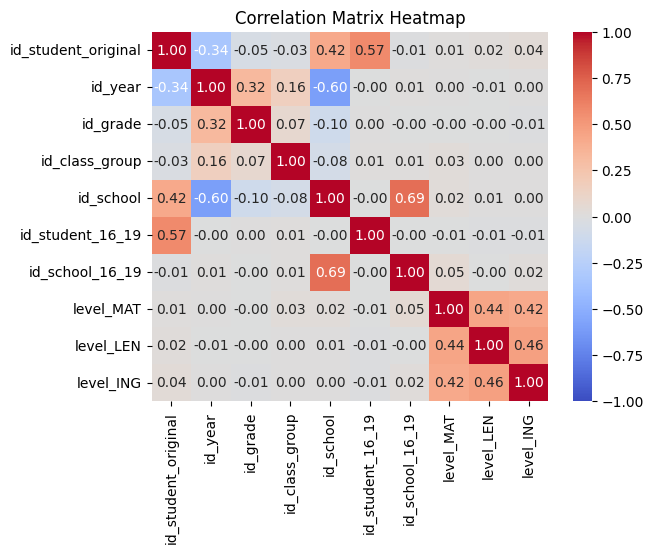

,id_student_original,id_year,id_grade,id_class_group,id_school,id_student_16_19,id_school_16_19,level_MAT,level_LEN,level_ING
id_questionnaire,,,,,,,,,,
1,33613.0,2016,3,A,2415.0,14374.0,569.0,3.0,3.0,NaN
2,19294.0,2016,3,A,1842.0,8001.0,273.0,1.0,1.0,NaN
3,19587.0,2016,3,NaN,1432.0,8142.0,82.0,1.0,3.0,NaN
4,29985.0,2016,3,A,2280.0,12800.0,505.0,2.0,2.0,NaN
5,6982.0,2016,3,A,2040.0,2606.0,390.0,4.0,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...
83853,2500.0,2019,6,B,1278.0,NaN,271.0,2.0,2.0,1.0
83854,5784.0,2019,6,A,1079.0,NaN,78.0,3.0,4.0,4.0
83855,7708.0,2019,6,X,1486.0,3036.0,459.0,4.0,2.0,2.0


,id_student_original,id_year,id_grade,id_class_group,id_school,id_student_16_19,id_school_16_19,level_MAT,level_LEN,level_ING
id_student_original,1.000000,-0.336732,-0.052204,-0.031246,0.417052,0.574448,-0.007898,0.014170,0.020464,0.038553
id_year,-0.336732,1.000000,0.324603,0.160981,-0.595819,-0.000049,0.010441,0.000758,-0.006925,0.002740
id_grade,-0.052204,0.324603,1.000000,0.073813,-0.103873,0.000538,-0.002465,-0.003471,-0.002249,-0.014849
id_class_group,-0.031246,0.160981,0.073813,1.000000,-0.077164,0.010418,0.007873,0.027510,0.004177,0.001292
id_school,0.417052,-0.595819,-0.103873,-0.077164,1.000000,-0.003389,0.688965,0.023545,0.005499,0.003349
id_student_16_19,0.574448,-0.000049,0.000538,0.010418,-0.003389,1.000000,-0.004426,-0.006985,-0.013151,-0.011873
id_school_16_19,-0.007898,0.010441,-0.002465,0.007873,0.688965,-0.004426,1.000000,0.053949,-0.004213,0.015791
level_MAT,0.014170,0.000758,-0.003471,0.027510,0.023545,-0.006985,0.053949,1.000000,0.438571,0.415471
level_LEN,0.020464,-0.006925,-0.002249,0.004177,0.005499,-0.013151,-0.004213,0.438571,1.000000,0.462179
level_ING,0.038553,0.002740,-0.014849,0.001292,0.003349,-0.011873,0.015791,0.415471,0.462179,1.000000


In [80]:
df_general, correlation_matrix_general = compute_exploratory_analysis(df=df, column_pattern="id_", missing_threshold=1.0, annot=True)

## General Info

GOOD FEATURES: 9
id_student_original    0.000000
id_year                0.000000
id_grade               0.000000
id_class_group         0.154667
id_school              0.000000
id_student_16_19       0.103898
id_school_16_19        0.062956
level_MAT              0.000000
level_LEN              0.009772
dtype: float64

BAD FEATURES
Series([], dtype: float64)



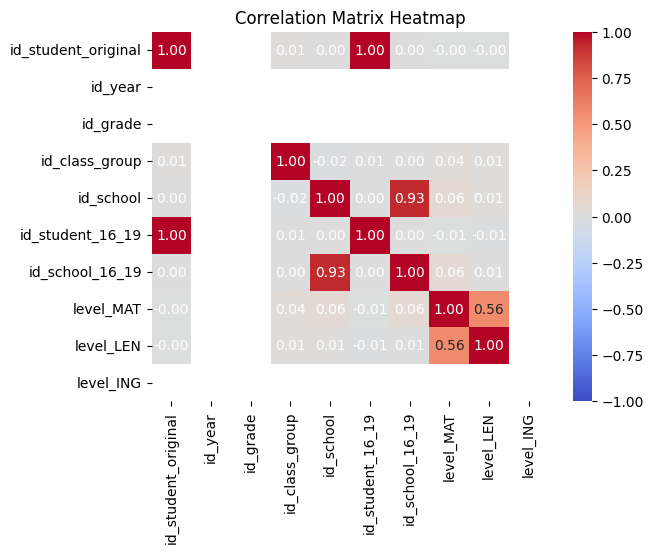

,id_student_original,id_year,id_grade,id_class_group,id_school,id_student_16_19,id_school_16_19,level_MAT,level_LEN,level_ING
id_questionnaire,,,,,,,,,,
1,33613.0,2016,3,A,2415.0,14374.0,569.0,3.0,3.0,NaN
2,19294.0,2016,3,A,1842.0,8001.0,273.0,1.0,1.0,NaN
3,19587.0,2016,3,NaN,1432.0,8142.0,82.0,1.0,3.0,NaN
4,29985.0,2016,3,A,2280.0,12800.0,505.0,2.0,2.0,NaN
5,6982.0,2016,3,A,2040.0,2606.0,390.0,4.0,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...
20426,5794.0,2016,3,NaN,1863.0,NaN,NaN,1.0,1.0,NaN
20427,3000.0,2016,3,A,2203.0,877.0,468.0,2.0,3.0,NaN
20428,36202.0,2016,3,B,1368.0,15545.0,51.0,2.0,2.0,NaN


,id_student_original,id_year,id_grade,id_class_group,id_school,id_student_16_19,id_school_16_19,level_MAT,level_LEN,level_ING
id_student_original,1.000000,NaN,NaN,0.008156,0.000439,0.999983,0.000417,-0.003242,-0.004734,NaN
id_year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_grade,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_class_group,0.008156,NaN,NaN,1.000000,-0.020820,0.005759,0.000943,0.042456,0.011373,NaN
id_school,0.000439,NaN,NaN,-0.020820,1.000000,0.000108,0.929463,0.061969,0.012964,NaN
id_student_16_19,0.999983,NaN,NaN,0.005759,0.000108,1.000000,0.000665,-0.006903,-0.010989,NaN
id_school_16_19,0.000417,NaN,NaN,0.000943,0.929463,0.000665,1.000000,0.059139,0.006073,NaN
level_MAT,-0.003242,NaN,NaN,0.042456,0.061969,-0.006903,0.059139,1.000000,0.562532,NaN
level_LEN,-0.004734,NaN,NaN,0.011373,0.012964,-0.010989,0.006073,0.562532,1.000000,NaN
level_ING,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [81]:
df_sel_gen, correlation_matrix_sel_gen = compute_exploratory_analysis(df=df_sel, column_pattern="id_", missing_threshold=1.0, annot=True)

## Student Questionnaire

GOOD FEATURES: 18
s_gender                             0.000056
s_birth_year                         0.050376
s_is_living_with_mother              0.071661
s_has_repeated                       0.081152
s_frequency_of_skips                 0.060261
s_homeworks_day_per_week             0.046894
s_extent_of_teachers_affinity        0.076772
s_frequency_of_computer_usage        0.056049
s_frequency_of_internet_usage        0.055824
s_frequency_of_work_with_teachers    0.056329
s_frequency_of_materials_in_class    0.059811
s_frequency_of_evaluations           0.058632
s_extent_of_teacher_performance      0.059025
s_extent_of_class_env                0.059250
s_extent_of_classmates_affinity      0.060036
s_extent_of_school_satisfaction      0.057396
level_MAT                            0.000000
level_LEN                            0.009772
dtype: float64

BAD FEATURES
s_is_living_with_father             0.137594
s_is_living_with_siblings           0.387229
s_is_living_with_other_relatives   

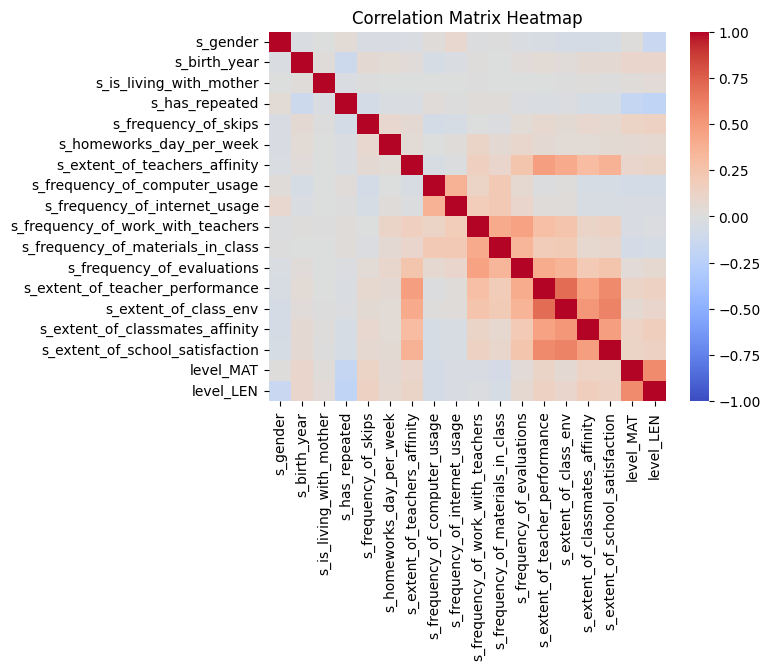

,s_gender,s_birth_year,s_is_living_with_mother,s_has_repeated,s_frequency_of_skips,s_homeworks_day_per_week,s_extent_of_teachers_affinity,s_frequency_of_computer_usage,s_frequency_of_internet_usage,s_frequency_of_work_with_teachers,s_frequency_of_materials_in_class,s_frequency_of_evaluations,s_extent_of_teacher_performance,s_extent_of_class_env,s_extent_of_classmates_affinity,s_extent_of_school_satisfaction,level_MAT,level_LEN
id_questionnaire,,,,,,,,,,,,,,,,,,
1,FEMALE,2007.0,True,False,1.000000,0.0,1.0,0.111111,0.066667,0.733333,0.380952,0.740741,0.833333,0.791667,0.714286,0.944444,3.0,3.0
2,MALE,2007.0,True,True,1.000000,3.0,1.0,0.333333,0.600000,0.533333,0.714286,0.888889,0.800000,0.791667,0.714286,1.000000,1.0,1.0
3,FEMALE,2007.0,True,False,1.000000,2.0,NaN,0.666667,0.666667,0.833333,1.000000,0.750000,0.800000,0.833333,0.833333,0.888889,1.0,3.0
4,MALE,2007.0,True,False,1.000000,3.0,1.0,0.333333,0.266667,0.400000,NaN,0.541667,0.800000,0.750000,0.857143,0.722222,2.0,2.0
5,FEMALE,2007.0,True,False,1.000000,1.0,1.0,0.000000,0.133333,0.566667,0.666667,0.888889,1.000000,1.000000,0.952381,1.000000,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20426,FEMALE,2001.0,True,NaN,0.000000,2.0,NaN,NaN,0.333333,0.333333,NaN,0.333333,0.333333,0.333333,0.333333,1.000000,1.0,1.0
20427,FEMALE,2007.0,True,False,1.000000,3.0,1.0,0.000000,0.133333,0.666667,0.476190,0.740741,0.900000,0.916667,0.857143,1.000000,2.0,3.0
20428,MALE,2001.0,True,NaN,0.333333,4.0,NaN,0.222222,0.933333,0.518519,0.777778,0.740741,0.566667,0.958333,0.666667,0.833333,2.0,2.0


,s_gender,s_birth_year,s_is_living_with_mother,s_has_repeated,s_frequency_of_skips,s_homeworks_day_per_week,s_extent_of_teachers_affinity,s_frequency_of_computer_usage,s_frequency_of_internet_usage,s_frequency_of_work_with_teachers,s_frequency_of_materials_in_class,s_frequency_of_evaluations,s_extent_of_teacher_performance,s_extent_of_class_env,s_extent_of_classmates_affinity,s_extent_of_school_satisfaction,level_MAT,level_LEN
s_gender,1.000000,-0.025734,-0.004612,0.040699,-0.032429,-0.031404,-0.028543,0.019260,0.084017,-0.013262,0.000793,-0.028531,-0.044767,-0.055349,-0.055421,-0.054659,0.015317,-0.144875
s_birth_year,-0.025734,1.000000,0.016656,-0.118357,0.054848,0.043845,0.028999,-0.054042,-0.026979,0.012553,-0.003437,0.030408,0.045375,0.029812,0.055133,0.057673,0.094234,0.101092
s_is_living_with_mother,-0.004612,0.016656,1.000000,-0.026872,0.007770,-0.000438,-0.002969,-0.006162,-0.004206,0.002344,-0.000594,-0.000971,-0.000717,0.000941,0.014985,0.007443,0.022023,0.036011
s_has_repeated,0.040699,-0.118357,-0.026872,1.000000,-0.076749,-0.030218,-0.024342,0.023778,0.007180,0.022051,0.020193,-0.017233,-0.030589,-0.021100,-0.049876,-0.054415,-0.164473,-0.201384
s_frequency_of_skips,-0.032429,0.054848,0.007770,-0.076749,1.000000,0.083523,0.057898,-0.077787,-0.052809,-0.003545,-0.018838,0.045844,0.077858,0.054547,0.079323,0.068743,0.122328,0.135020
s_homeworks_day_per_week,-0.031404,0.043845,-0.000438,-0.030218,0.083523,1.000000,0.042352,-0.001209,0.020738,0.110804,0.059834,0.091831,0.057171,0.046462,0.042416,0.049517,0.058022,0.069309
s_extent_of_teachers_affinity,-0.028543,0.028999,-0.002969,-0.024342,0.057898,0.042352,1.000000,-0.039669,-0.008730,0.161501,0.094192,0.248668,0.469525,0.409045,0.308001,0.370532,0.093792,0.116560
s_frequency_of_computer_usage,0.019260,-0.054042,-0.006162,0.023778,-0.077787,-0.001209,-0.039669,1.000000,0.371735,0.120296,0.215274,0.064127,-0.011863,0.014833,-0.052212,-0.051609,-0.072532,-0.075436
s_frequency_of_internet_usage,0.084017,-0.026979,-0.004206,0.007180,-0.052809,0.020738,-0.008730,0.371735,1.000000,0.184811,0.215844,0.097839,0.020481,0.022687,-0.043809,-0.039423,-0.036665,-0.037401
s_frequency_of_work_with_teachers,-0.013262,0.012553,0.002344,0.022051,-0.003545,0.110804,0.161501,0.120296,0.184811,1.000000,0.407241,0.459210,0.284243,0.253826,0.115582,0.140080,-0.038320,-0.016607


In [82]:
df_sel_students, correlation_matrix_sel_students = compute_exploratory_analysis(df=df_sel, column_pattern="s_", missing_threshold=0.095, annot=False)

## Family Questionnaire

GOOD FEATURES: 23
f_respondent                                           0.288217
f_number_of_people_in_household                        0.299562
f_mother_age                                           0.281534
f_mother_education_level                               0.291082
f_student_place_of_birth                               0.287768
f_language_spoken_at_home                              0.287937
f_degree_of_start_schooling_age                        0.293665
f_number_of_tech_at_home                               0.281984
f_extent_of_books_at_home                              0.274907
f_visits_in_school_by_mother                           0.289790
f_has_been_recommended_school                          0.282882
f_number_of_homework_hours_a_week                      0.278445
f_ESCS                                                 0.275357
f_frequency_of_books_at_home                           0.290295
f_frequency_of_tech_at_home                            0.291531
f_frequency_of_see_adu

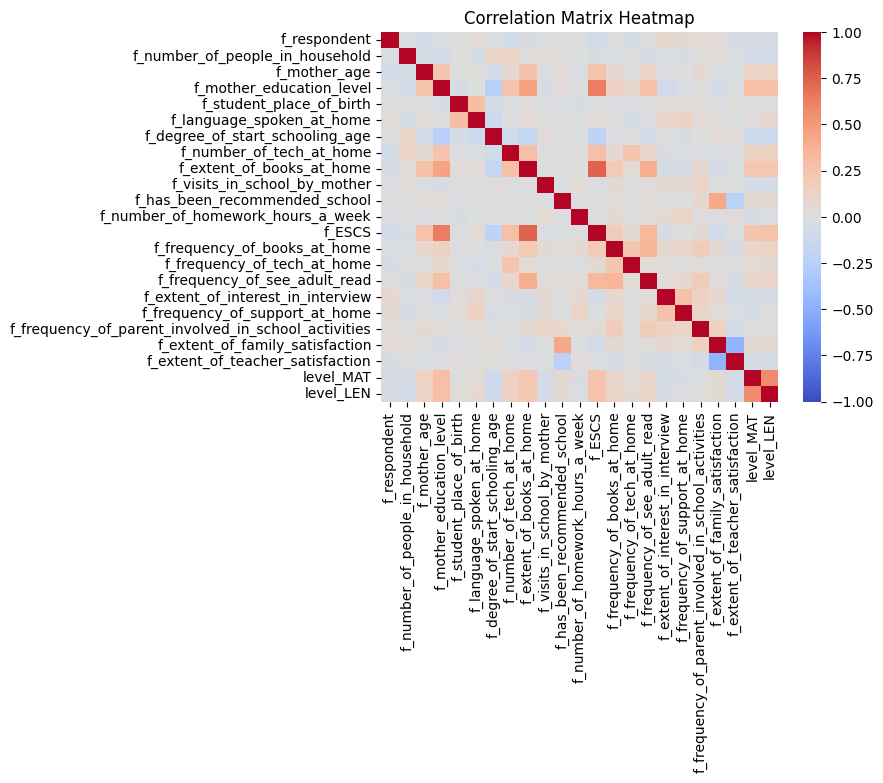

,f_respondent,f_number_of_people_in_household,f_mother_age,f_mother_education_level,f_student_place_of_birth,f_language_spoken_at_home,f_degree_of_start_schooling_age,f_number_of_tech_at_home,f_extent_of_books_at_home,f_visits_in_school_by_mother,...,f_frequency_of_books_at_home,f_frequency_of_tech_at_home,f_frequency_of_see_adult_read,f_extent_of_interest_in_interview,f_frequency_of_support_at_home,f_frequency_of_parent_involved_in_school_activities,f_extent_of_family_satisfaction,f_extent_of_teacher_satisfaction,level_MAT,level_LEN
id_questionnaire,,,,,,,,,,,,,,,,,,,,,
1,MOTHER,3.0,43.0,7.0,CANARY_ISLANDS,SPANISH,1.0,3.0,0.75,ONCE_PER_WEEK,...,1.000000,1.000000,0.625,1.000000,1.000000,0.333333,0.700000,0.15,3.0,3.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
3,MOTHER,4.0,45.0,3.0,CANARY_ISLANDS,SPANISH,1.0,4.0,0.25,ONCE_PER_MONTH,...,0.444444,0.333333,0.250,1.000000,1.000000,0.166667,0.291667,0.50,1.0,3.0
4,MOTHER,4.0,39.0,5.0,CANARY_ISLANDS,SPANISH,1.0,3.0,0.75,ONCE_PER_WEEK,...,0.333333,0.333333,0.500,1.000000,1.000000,0.250000,1.000000,0.20,2.0,2.0
5,FATHER,4.0,39.0,9.0,CANARY_ISLANDS,SPANISH,1.0,7.0,1.00,ONCE_PER_MONTH,...,0.555556,0.500000,0.625,NaN,0.888889,0.250000,0.833333,0.35,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20426,FATHER,3.0,31.0,3.0,CANARY_ISLANDS,SPANISH,2.0,4.0,0.00,NaN,...,0.333333,1.000000,0.000,0.444444,0.800000,0.000000,0.791667,0.25,1.0,1.0
20427,MOTHER,3.0,37.0,5.0,CANARY_ISLANDS,SPANISH,2.0,5.0,0.50,SOMETIMES,...,0.444444,0.666667,0.500,0.500000,0.888889,0.000000,0.291667,0.40,2.0,3.0
20428,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0


,f_respondent,f_number_of_people_in_household,f_mother_age,f_mother_education_level,f_student_place_of_birth,f_language_spoken_at_home,f_degree_of_start_schooling_age,f_number_of_tech_at_home,f_extent_of_books_at_home,f_visits_in_school_by_mother,...,f_frequency_of_books_at_home,f_frequency_of_tech_at_home,f_frequency_of_see_adult_read,f_extent_of_interest_in_interview,f_frequency_of_support_at_home,f_frequency_of_parent_involved_in_school_activities,f_extent_of_family_satisfaction,f_extent_of_teacher_satisfaction,level_MAT,level_LEN
f_respondent,1.000000,-0.027957,-0.081211,-0.027144,-0.006793,0.041598,-0.014239,-0.084977,-0.038491,-0.017420,...,-0.008995,-0.053953,0.015517,0.074843,0.054338,0.046602,0.037620,-0.032144,-0.040162,-0.044839
f_number_of_people_in_household,-0.027957,1.000000,-0.053139,-0.088100,0.010731,-0.052196,0.108799,0.123348,0.011982,0.016202,...,-0.025456,-0.010474,-0.031906,-0.026799,-0.042393,0.009101,0.031290,-0.011043,-0.067898,-0.076081
f_mother_age,-0.081211,-0.053139,1.000000,0.250886,-0.002140,0.022580,-0.072617,0.058864,0.268057,-0.015672,...,0.072558,-0.011576,0.110363,-0.029604,-0.002376,0.060719,-0.013724,-0.024134,0.126018,0.129967
f_mother_education_level,-0.027144,-0.088100,0.250886,1.000000,-0.049596,-0.002979,-0.248467,0.254568,0.457494,-0.042295,...,0.146603,0.074593,0.284140,-0.089370,-0.030900,0.020266,-0.065329,-0.018038,0.284138,0.283595
f_student_place_of_birth,-0.006793,0.010731,-0.002140,-0.049596,1.000000,0.289808,-0.072643,-0.015643,0.025610,-0.012835,...,-0.017911,-0.020781,-0.012698,0.026882,0.044377,0.011125,-0.020163,0.021383,0.000980,0.020267
f_language_spoken_at_home,0.041598,-0.052196,0.022580,-0.002979,0.289808,1.000000,-0.112067,-0.008967,0.035558,-0.004309,...,-0.006676,-0.049509,-0.021653,0.091814,0.141668,0.035891,0.014853,-0.003008,0.025272,0.066332
f_degree_of_start_schooling_age,-0.014239,0.108799,-0.072617,-0.248467,-0.072643,-0.112067,1.000000,-0.098786,-0.170949,0.027965,...,-0.021553,-0.002300,-0.076068,-0.004336,-0.034542,-0.006201,0.036661,0.015961,-0.115373,-0.108522
f_number_of_tech_at_home,-0.084977,0.123348,0.058864,0.254568,-0.015643,-0.008967,-0.098786,1.000000,0.283857,-0.007627,...,0.063726,0.241223,0.100015,-0.036621,-0.026188,-0.011387,-0.030832,-0.012458,0.143473,0.146762
f_extent_of_books_at_home,-0.038491,0.011982,0.268057,0.457494,0.025610,0.035558,-0.170949,0.283857,1.000000,-0.011430,...,0.209352,0.043936,0.385506,-0.062068,-0.033528,0.066643,-0.066426,-0.022848,0.229863,0.231046
f_visits_in_school_by_mother,-0.017420,0.016202,-0.015672,-0.042295,-0.012835,-0.004309,0.027965,-0.007627,-0.011430,1.000000,...,0.048104,0.012176,0.030557,0.063744,0.054227,0.101717,-0.002028,-0.008348,-0.056037,-0.055724


In [83]:
df_sel_families, correlation_matrix_sel_families = compute_exploratory_analysis(df=df_sel, column_pattern="f_", missing_threshold=0.3, annot=False)

## Teacher Questionnaire

GOOD FEATURES: 31
t_gender                                        0.273054
t_age                                           0.291643
t_number_of_years_as_teacher                    0.276424
t_number_of_years_in_school                     0.283444
t_has_taught_same_group_last_two_years          0.273110
t_number_of_students_in_group                   0.275525
t_number_of_teaching_hours_per_week             0.286982
t_average_explanation_time                      0.270920
t_degree_of_individual_training_incidence       0.347130
t_seat_configuration                            0.273447
t_behaviour_problems_solution                   0.275750
t_number_of_meetings_with_families              0.308267
t_is_enrolled_in_school_training_plan           0.273503
t_number_of_training_hours_last_six_years       0.331854
t_extent_of_evaluation_variety                  0.271032
t_extent_of_pfc_incidence                       0.335617
t_extent_of_work_hampered                       0.274907
t_extent_of_f

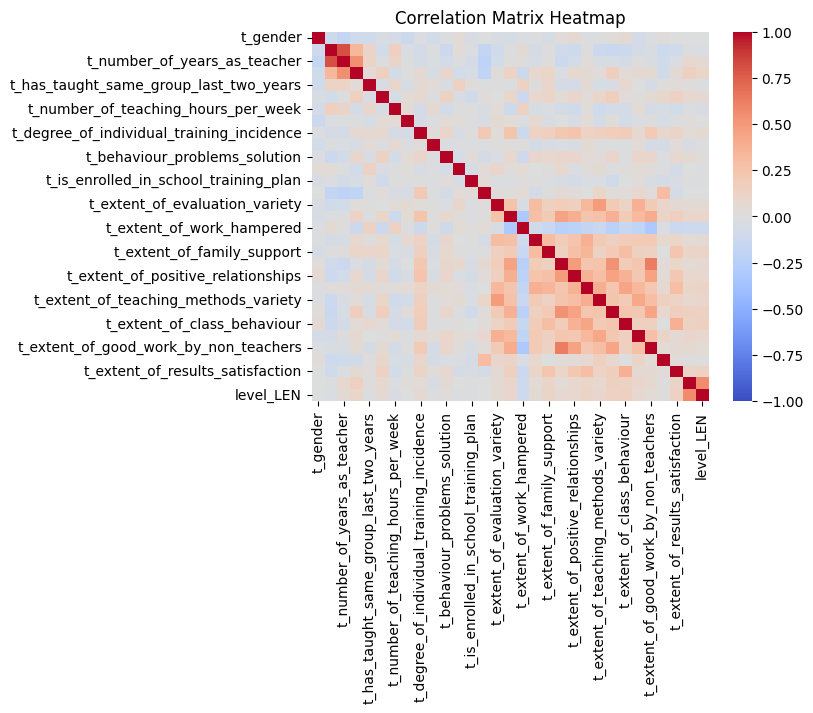

,t_gender,t_age,t_number_of_years_as_teacher,t_number_of_years_in_school,t_has_taught_same_group_last_two_years,t_number_of_students_in_group,t_number_of_teaching_hours_per_week,t_average_explanation_time,t_degree_of_individual_training_incidence,t_seat_configuration,...,t_extent_of_student_involvement_during_class,t_extent_of_teaching_methods_variety,t_extent_of_opinion_on_school,t_extent_of_class_behaviour,t_extent_of_resource_variety,t_extent_of_good_work_by_non_teachers,t_number_of_individual_training_topics,t_extent_of_results_satisfaction,level_MAT,level_LEN
id_questionnaire,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.0
4,FEMALE,56.0,29.0,18.0,False,26.0,15.0,2.0,NaN,5.0,...,0.555556,0.666667,1.000000,0.500000,0.458333,0.555556,NaN,0.666667,2.0,2.0
5,FEMALE,44.0,20.0,17.0,False,26.0,18.0,2.0,4.0,5.0,...,0.666667,0.733333,1.000000,0.833333,0.625000,0.888889,1.0,1.000000,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20426,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
20427,FEMALE,48.0,27.0,11.0,False,25.0,18.0,2.0,4.0,4.0,...,0.600000,0.600000,1.000000,0.666667,0.571429,0.888889,2.0,0.666667,2.0,3.0
20428,MALE,34.0,7.0,1.0,False,26.0,12.0,2.0,NaN,2.0,...,0.500000,0.733333,0.666667,0.666667,0.583333,0.777778,NaN,0.666667,2.0,2.0


,t_gender,t_age,t_number_of_years_as_teacher,t_number_of_years_in_school,t_has_taught_same_group_last_two_years,t_number_of_students_in_group,t_number_of_teaching_hours_per_week,t_average_explanation_time,t_degree_of_individual_training_incidence,t_seat_configuration,...,t_extent_of_student_involvement_during_class,t_extent_of_teaching_methods_variety,t_extent_of_opinion_on_school,t_extent_of_class_behaviour,t_extent_of_resource_variety,t_extent_of_good_work_by_non_teachers,t_number_of_individual_training_topics,t_extent_of_results_satisfaction,level_MAT,level_LEN
t_gender,1.000000,-0.106988,-0.164927,-0.100052,-0.099470,-0.039606,-0.063430,-0.120649,-0.018532,-0.084971,...,-0.020070,-0.009020,0.015698,0.062479,-0.066329,-0.022120,0.017530,-0.004949,-0.000143,-0.005552
t_age,-0.106988,1.000000,0.805214,0.342080,0.112678,-0.084781,0.161169,-0.026750,-0.070094,-0.007977,...,0.012214,-0.125742,-0.135391,-0.124766,-0.065868,-0.041972,-0.112589,-0.096093,-0.008295,-0.024233
t_number_of_years_as_teacher,-0.164927,0.805214,1.000000,0.551866,0.120687,-0.012364,0.112551,-0.013882,-0.059970,-0.027214,...,0.024339,-0.046590,-0.047873,-0.063738,0.007308,-0.042023,-0.098857,-0.028828,0.075011,0.050907
t_number_of_years_in_school,-0.100052,0.342080,0.551866,1.000000,0.038472,0.148874,-0.077058,0.002995,0.059977,-0.040416,...,0.047081,0.024319,0.168196,0.041879,0.056558,0.052474,-0.087610,0.052541,0.151830,0.108267
t_has_taught_same_group_last_two_years,-0.099470,0.112678,0.120687,0.038472,1.000000,-0.032484,0.089767,-0.048343,0.055218,0.038558,...,0.049167,-0.050967,-0.037333,0.085873,-0.000101,-0.060428,0.014706,0.029821,0.007877,-0.012844
t_number_of_students_in_group,-0.039606,-0.084781,-0.012364,0.148874,-0.032484,1.000000,-0.053343,0.040897,0.065211,-0.009042,...,0.023562,0.108129,0.166899,0.025933,0.014967,0.054066,0.090980,0.133450,0.072164,0.062272
t_number_of_teaching_hours_per_week,-0.063430,0.161169,0.112551,-0.077058,0.089767,-0.053343,1.000000,0.042068,-0.067785,0.066526,...,0.022033,-0.093943,-0.064910,-0.067174,0.044952,-0.066695,-0.050515,-0.078304,-0.025020,-0.032582
t_average_explanation_time,-0.120649,-0.026750,-0.013882,0.002995,-0.048343,0.040897,0.042068,1.000000,-0.058005,-0.020963,...,0.032047,-0.075840,0.019898,-0.082599,-0.017647,0.007743,-0.050090,-0.013376,0.021821,-0.007260
t_degree_of_individual_training_incidence,-0.018532,-0.070094,-0.059970,0.059977,0.055218,0.065211,-0.067785,-0.058005,1.000000,0.021087,...,0.125704,0.155654,0.186371,0.177928,0.067379,0.203504,0.088132,0.112130,0.044813,0.058198
t_seat_configuration,-0.084971,-0.007977,-0.027214,-0.040416,0.038558,-0.009042,0.066526,-0.020963,0.021087,1.000000,...,0.049695,0.001414,-0.012346,-0.010096,0.037983,-0.070059,-0.059415,0.027751,-0.036483,-0.014880


In [84]:
df_sel_teachers, correlation_matrix_sel_teachers = compute_exploratory_analysis(df=df_sel, column_pattern="t_", missing_threshold=0.4, annot=False)

## Principals Questionnaire

GOOD FEATURES: 35
p_gender                                             0.048916
p_number_of_teachers_in_school                       0.055318
p_percentage_of_teachers_changed_school_last_year    0.050264
p_attitude_teacher_training_courses                  0.056105
p_age                                                0.051724
p_group_criteria_random                              0.000000
p_group_criteria_subjects                            0.000000
p_group_criteria_other                               0.000000
p_group_criteria_alphabet                            0.000000
p_group_criteria_gender                              0.000000
p_group_criteria_language                            0.000000
p_group_criteria_performance                         0.000000
p_group_criteria_homogeneity                         0.000000
p_group_criteria_heterogeneity                       0.000000
p_number_of_years_of_teaching                        0.058520
p_number_of_years_in_school                         

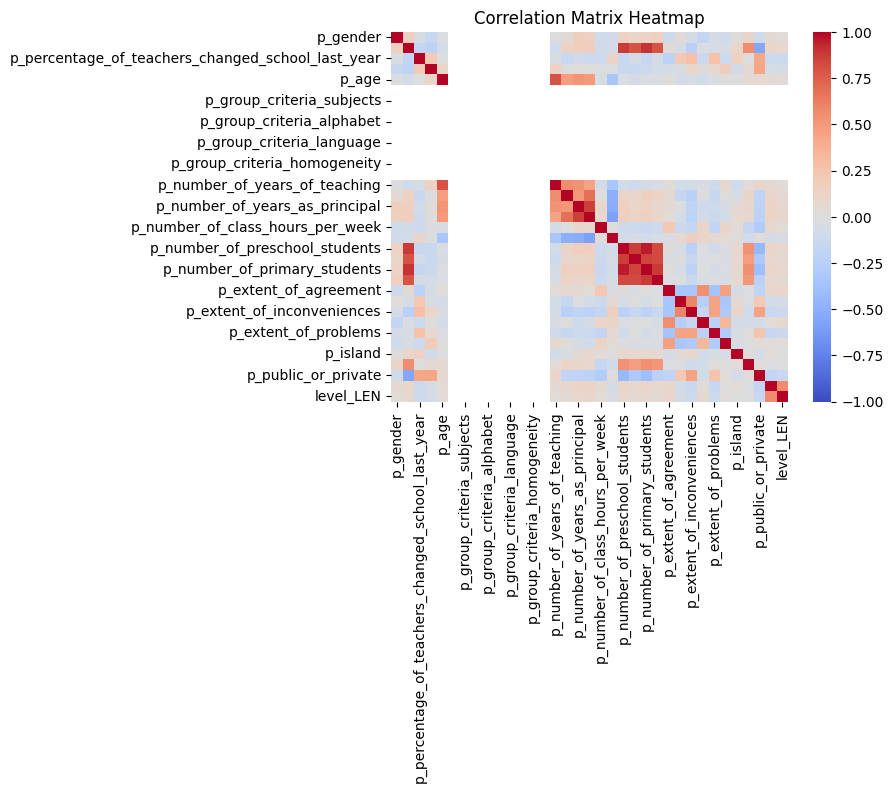

,p_gender,p_number_of_teachers_in_school,p_percentage_of_teachers_changed_school_last_year,p_attitude_teacher_training_courses,p_age,p_group_criteria_random,p_group_criteria_subjects,p_group_criteria_other,p_group_criteria_alphabet,p_group_criteria_gender,...,p_extent_of_factors_limiting_effectiveness,p_extent_of_inconveniences,p_extent_of_management,p_extent_of_problems,p_extent_of_satisfaction,p_island,p_number_of_school_tech_resources,p_public_or_private,level_MAT,level_LEN
id_questionnaire,,,,,,,,,,,,,,,,,,,,,
1,MALE,19.0,3.0,3.0,50.0,False,False,False,False,False,...,0.666667,0.750000,0.666667,0.314815,0.611111,TENERIFE_CAPITAL,196.0,PUBLIC,3.0,3.0
2,FEMALE,26.0,2.0,3.0,58.0,False,False,False,False,False,...,0.375000,0.305556,0.857143,0.074074,0.888889,GRAN_CANARIA_CAPITAL,157.0,PUBLIC,1.0,1.0
3,FEMALE,42.0,2.0,2.0,45.0,False,False,False,False,False,...,0.500000,0.606061,0.666667,0.314815,0.666667,GRAN_CANARIA_CAPITAL,62.0,PRIVATE,1.0,3.0
4,MALE,15.0,1.0,3.0,46.0,False,False,False,False,False,...,0.625000,0.666667,0.809524,0.129630,0.555556,TENERIFE_CAPITAL,131.0,PUBLIC,2.0,2.0
5,MALE,22.0,1.0,2.0,56.0,False,False,False,False,False,...,0.458333,0.333333,0.714286,0.055556,0.722222,TENERIFE_CAPITAL,118.0,PRIVATE,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20426,FEMALE,24.0,4.0,3.0,46.0,False,False,False,False,False,...,0.583333,0.555556,0.952381,0.129630,0.666667,GRAN_CANARIA_PROVINCE,264.0,PUBLIC,1.0,1.0
20427,FEMALE,15.0,2.0,3.0,49.0,False,False,False,False,False,...,0.333333,0.416667,0.761905,0.055556,0.777778,TENERIFE_CAPITAL,178.0,PUBLIC,2.0,3.0
20428,MALE,27.0,1.0,3.0,59.0,False,False,False,False,False,...,0.458333,0.388889,0.809524,0.156863,0.888889,GRAN_CANARIA_CAPITAL,311.0,PUBLIC,2.0,2.0


,p_gender,p_number_of_teachers_in_school,p_percentage_of_teachers_changed_school_last_year,p_attitude_teacher_training_courses,p_age,p_group_criteria_random,p_group_criteria_subjects,p_group_criteria_other,p_group_criteria_alphabet,p_group_criteria_gender,...,p_extent_of_factors_limiting_effectiveness,p_extent_of_inconveniences,p_extent_of_management,p_extent_of_problems,p_extent_of_satisfaction,p_island,p_number_of_school_tech_resources,p_public_or_private,level_MAT,level_LEN
p_gender,1.000000,0.159623,-0.045782,-0.155428,-0.024211,NaN,NaN,NaN,NaN,NaN,...,0.038589,-0.067401,-0.176006,-0.056263,-0.095692,0.009655,0.111593,-0.099218,0.053646,0.044194
p_number_of_teachers_in_school,0.159623,1.000000,-0.185265,-0.215315,-0.071810,NaN,NaN,NaN,NaN,NaN,...,-0.061530,-0.240613,-0.027679,-0.054402,-0.041268,0.107208,0.556685,-0.547485,0.102478,0.085440
p_percentage_of_teachers_changed_school_last_year,-0.045782,-0.185265,1.000000,0.201196,-0.004783,NaN,NaN,NaN,NaN,NaN,...,0.212428,0.281746,-0.120551,0.262679,-0.113346,0.135192,0.004551,0.434857,-0.132012,-0.124095
p_attitude_teacher_training_courses,-0.155428,-0.215315,0.201196,1.000000,0.106640,NaN,NaN,NaN,NaN,NaN,...,-0.044016,0.101608,0.010726,0.083005,0.173843,-0.087793,0.059893,0.444140,-0.053197,-0.061591
p_age,-0.024211,-0.071810,-0.004783,0.106640,1.000000,NaN,NaN,NaN,NaN,NaN,...,-0.066245,-0.045046,-0.085886,-0.030693,0.014912,0.003910,0.061936,0.072827,0.044703,0.037460
p_group_criteria_random,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
p_group_criteria_subjects,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
p_group_criteria_other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
p_group_criteria_alphabet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
p_group_criteria_gender,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [85]:
df_sel_principals, correlation_matrix_sel_principals = compute_exploratory_analysis(df=df_sel, column_pattern="p_", missing_threshold=0.1, annot=False)

GOOD FEATURES: 34
p_gender                                             0.048916
p_number_of_teachers_in_school                       0.055318
p_percentage_of_teachers_changed_school_last_year    0.050264
p_attitude_teacher_training_courses                  0.056105
p_age                                                0.051724
p_group_criteria_random                              0.000000
p_group_criteria_subjects                            0.000000
p_group_criteria_other                               0.000000
p_group_criteria_alphabet                            0.000000
p_group_criteria_gender                              0.000000
p_group_criteria_language                            0.000000
p_group_criteria_performance                         0.000000
p_group_criteria_homogeneity                         0.000000
p_group_criteria_heterogeneity                       0.000000
p_number_of_years_of_teaching                        0.058520
p_number_of_years_in_school                         

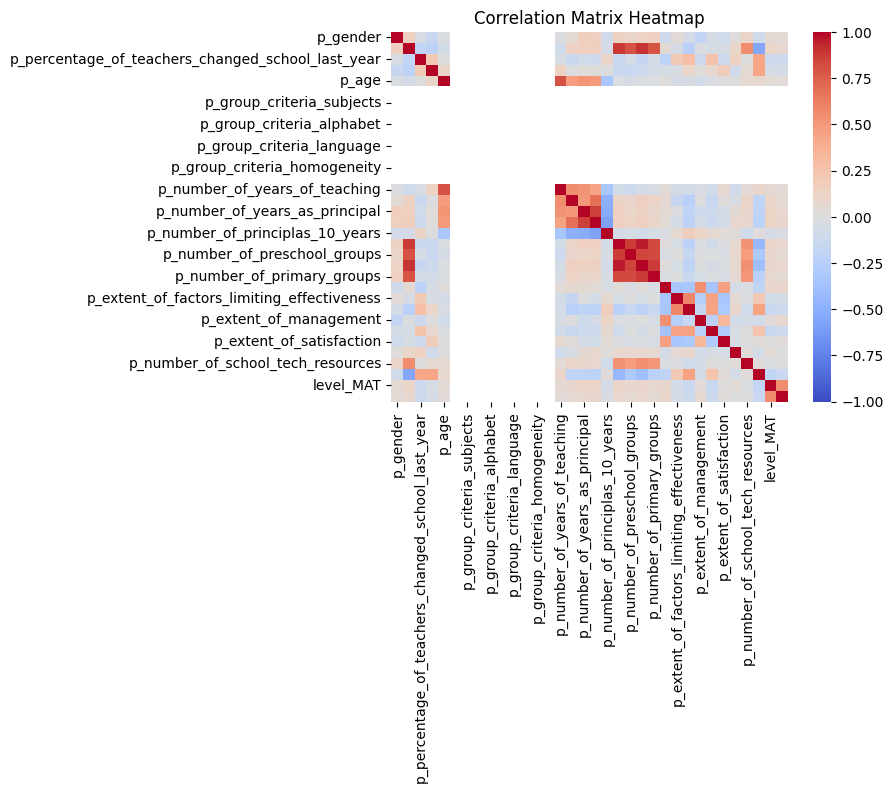

,p_gender,p_number_of_teachers_in_school,p_percentage_of_teachers_changed_school_last_year,p_attitude_teacher_training_courses,p_age,p_group_criteria_random,p_group_criteria_subjects,p_group_criteria_other,p_group_criteria_alphabet,p_group_criteria_gender,...,p_extent_of_factors_limiting_effectiveness,p_extent_of_inconveniences,p_extent_of_management,p_extent_of_problems,p_extent_of_satisfaction,p_island,p_number_of_school_tech_resources,p_public_or_private,level_MAT,level_LEN
id_questionnaire,,,,,,,,,,,,,,,,,,,,,
1,MALE,19.0,3.0,3.0,50.0,False,False,False,False,False,...,0.666667,0.750000,0.666667,0.314815,0.611111,TENERIFE_CAPITAL,196.0,PUBLIC,3.0,3.0
2,FEMALE,26.0,2.0,3.0,58.0,False,False,False,False,False,...,0.375000,0.305556,0.857143,0.074074,0.888889,GRAN_CANARIA_CAPITAL,157.0,PUBLIC,1.0,1.0
3,FEMALE,42.0,2.0,2.0,45.0,False,False,False,False,False,...,0.500000,0.606061,0.666667,0.314815,0.666667,GRAN_CANARIA_CAPITAL,62.0,PRIVATE,1.0,3.0
4,MALE,15.0,1.0,3.0,46.0,False,False,False,False,False,...,0.625000,0.666667,0.809524,0.129630,0.555556,TENERIFE_CAPITAL,131.0,PUBLIC,2.0,2.0
5,MALE,22.0,1.0,2.0,56.0,False,False,False,False,False,...,0.458333,0.333333,0.714286,0.055556,0.722222,TENERIFE_CAPITAL,118.0,PRIVATE,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20426,FEMALE,24.0,4.0,3.0,46.0,False,False,False,False,False,...,0.583333,0.555556,0.952381,0.129630,0.666667,GRAN_CANARIA_PROVINCE,264.0,PUBLIC,1.0,1.0
20427,FEMALE,15.0,2.0,3.0,49.0,False,False,False,False,False,...,0.333333,0.416667,0.761905,0.055556,0.777778,TENERIFE_CAPITAL,178.0,PUBLIC,2.0,3.0
20428,MALE,27.0,1.0,3.0,59.0,False,False,False,False,False,...,0.458333,0.388889,0.809524,0.156863,0.888889,GRAN_CANARIA_CAPITAL,311.0,PUBLIC,2.0,2.0


,p_gender,p_number_of_teachers_in_school,p_percentage_of_teachers_changed_school_last_year,p_attitude_teacher_training_courses,p_age,p_group_criteria_random,p_group_criteria_subjects,p_group_criteria_other,p_group_criteria_alphabet,p_group_criteria_gender,...,p_extent_of_factors_limiting_effectiveness,p_extent_of_inconveniences,p_extent_of_management,p_extent_of_problems,p_extent_of_satisfaction,p_island,p_number_of_school_tech_resources,p_public_or_private,level_MAT,level_LEN
p_gender,1.000000,0.159623,-0.045782,-0.155428,-0.024211,NaN,NaN,NaN,NaN,NaN,...,0.038589,-0.067401,-0.176006,-0.056263,-0.095692,0.009655,0.111593,-0.099218,0.053646,0.044194
p_number_of_teachers_in_school,0.159623,1.000000,-0.185265,-0.215315,-0.071810,NaN,NaN,NaN,NaN,NaN,...,-0.061530,-0.240613,-0.027679,-0.054402,-0.041268,0.107208,0.556685,-0.547485,0.102478,0.085440
p_percentage_of_teachers_changed_school_last_year,-0.045782,-0.185265,1.000000,0.201196,-0.004783,NaN,NaN,NaN,NaN,NaN,...,0.212428,0.281746,-0.120551,0.262679,-0.113346,0.135192,0.004551,0.434857,-0.132012,-0.124095
p_attitude_teacher_training_courses,-0.155428,-0.215315,0.201196,1.000000,0.106640,NaN,NaN,NaN,NaN,NaN,...,-0.044016,0.101608,0.010726,0.083005,0.173843,-0.087793,0.059893,0.444140,-0.053197,-0.061591
p_age,-0.024211,-0.071810,-0.004783,0.106640,1.000000,NaN,NaN,NaN,NaN,NaN,...,-0.066245,-0.045046,-0.085886,-0.030693,0.014912,0.003910,0.061936,0.072827,0.044703,0.037460
p_group_criteria_random,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
p_group_criteria_subjects,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
p_group_criteria_other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
p_group_criteria_alphabet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
p_group_criteria_gender,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,p_gender,p_number_of_teachers_in_school,p_percentage_of_teachers_changed_school_last_year,p_attitude_teacher_training_courses,p_age,p_group_criteria_random,p_group_criteria_subjects,p_group_criteria_other,p_group_criteria_alphabet,p_group_criteria_gender,...,p_extent_of_factors_limiting_effectiveness,p_extent_of_inconveniences,p_extent_of_management,p_extent_of_problems,p_extent_of_satisfaction,p_island,p_number_of_school_tech_resources,p_public_or_private,level_MAT,level_LEN
id_questionnaire,,,,,,,,,,,,,,,,,,,,,
1,MALE,19.0,3.0,3.0,50.0,False,False,False,False,False,...,0.666667,0.750000,0.666667,0.314815,0.611111,TENERIFE_CAPITAL,196.0,PUBLIC,3.0,3.0
2,FEMALE,26.0,2.0,3.0,58.0,False,False,False,False,False,...,0.375000,0.305556,0.857143,0.074074,0.888889,GRAN_CANARIA_CAPITAL,157.0,PUBLIC,1.0,1.0
3,FEMALE,42.0,2.0,2.0,45.0,False,False,False,False,False,...,0.500000,0.606061,0.666667,0.314815,0.666667,GRAN_CANARIA_CAPITAL,62.0,PRIVATE,1.0,3.0
4,MALE,15.0,1.0,3.0,46.0,False,False,False,False,False,...,0.625000,0.666667,0.809524,0.129630,0.555556,TENERIFE_CAPITAL,131.0,PUBLIC,2.0,2.0
5,MALE,22.0,1.0,2.0,56.0,False,False,False,False,False,...,0.458333,0.333333,0.714286,0.055556,0.722222,TENERIFE_CAPITAL,118.0,PRIVATE,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20426,FEMALE,24.0,4.0,3.0,46.0,False,False,False,False,False,...,0.583333,0.555556,0.952381,0.129630,0.666667,GRAN_CANARIA_PROVINCE,264.0,PUBLIC,1.0,1.0
20427,FEMALE,15.0,2.0,3.0,49.0,False,False,False,False,False,...,0.333333,0.416667,0.761905,0.055556,0.777778,TENERIFE_CAPITAL,178.0,PUBLIC,2.0,3.0
20428,MALE,27.0,1.0,3.0,59.0,False,False,False,False,False,...,0.458333,0.388889,0.809524,0.156863,0.888889,GRAN_CANARIA_CAPITAL,311.0,PUBLIC,2.0,2.0


In [86]:
df_sel_principals, _ = compute_exploratory_analysis(df=df_sel, column_pattern="p_", missing_threshold=0.09, annot=False)
df_sel_principals

# Feature Importance

In [87]:
target_feature = "level_MAT"

## Utils

In [88]:
get_features = lambda curr_df: [col for col in curr_df.columns if not col.startswith("level_")]

## Core

In [89]:
get_features = lambda curr_df: [col for col in curr_df.columns if not col.startswith("level_")]
concatenated_df = pd.concat(
    [
        df_sel_gen[["id_class_group", "id_school", target_feature]],
        df_sel_students[get_features(df_sel_students)],
        df_sel_families[get_features(df_sel_families)],
        df_sel_teachers[get_features(df_sel_teachers)],
        df_sel_principals[get_features(df_sel_principals)]
    ],
    axis=1
)
X, y = concatenated_df[get_features(concatenated_df)], concatenated_df[target_feature]
X

,id_class_group,id_school,s_gender,s_birth_year,s_is_living_with_mother,s_has_repeated,s_frequency_of_skips,s_homeworks_day_per_week,s_extent_of_teachers_affinity,s_frequency_of_computer_usage,...,p_number_of_primary_groups,p_extent_of_agreement,p_extent_of_factors_limiting_effectiveness,p_extent_of_inconveniences,p_extent_of_management,p_extent_of_problems,p_extent_of_satisfaction,p_island,p_number_of_school_tech_resources,p_public_or_private
id_questionnaire,,,,,,,,,,,,,,,,,,,,,
1,A,2415.0,FEMALE,2007.0,True,False,1.000000,0.0,1.0,0.111111,...,10.0,0.611111,0.666667,0.750000,0.666667,0.314815,0.611111,TENERIFE_CAPITAL,196.0,PUBLIC
2,A,1842.0,MALE,2007.0,True,True,1.000000,3.0,1.0,0.333333,...,12.0,0.666667,0.375000,0.305556,0.857143,0.074074,0.888889,GRAN_CANARIA_CAPITAL,157.0,PUBLIC
3,NaN,1432.0,FEMALE,2007.0,True,False,1.000000,2.0,NaN,0.666667,...,12.0,0.666667,0.500000,0.606061,0.666667,0.314815,0.666667,GRAN_CANARIA_CAPITAL,62.0,PRIVATE
4,A,2280.0,MALE,2007.0,True,False,1.000000,3.0,1.0,0.333333,...,6.0,0.444444,0.625000,0.666667,0.809524,0.129630,0.555556,TENERIFE_CAPITAL,131.0,PUBLIC
5,A,2040.0,FEMALE,2007.0,True,False,1.000000,1.0,1.0,0.000000,...,6.0,0.722222,0.458333,0.333333,0.714286,0.055556,0.722222,TENERIFE_CAPITAL,118.0,PRIVATE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20426,NaN,1863.0,FEMALE,2001.0,True,NaN,0.000000,2.0,NaN,NaN,...,10.0,0.444444,0.583333,0.555556,0.952381,0.129630,0.666667,GRAN_CANARIA_PROVINCE,264.0,PUBLIC
20427,A,2203.0,FEMALE,2007.0,True,False,1.000000,3.0,1.0,0.000000,...,6.0,0.611111,0.333333,0.416667,0.761905,0.055556,0.777778,TENERIFE_CAPITAL,178.0,PUBLIC
20428,B,1368.0,MALE,2001.0,True,NaN,0.333333,4.0,NaN,0.222222,...,12.0,0.722222,0.458333,0.388889,0.809524,0.156863,0.888889,GRAN_CANARIA_CAPITAL,311.0,PUBLIC


In [90]:
forest = RandomForestClassifier(random_state=0)
forest.fit(discretize_columns(X), y)

RandomForestClassifier(random_state=0)

In [91]:
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)

Text(0, 0.5, 'Mean decrease in impurity')

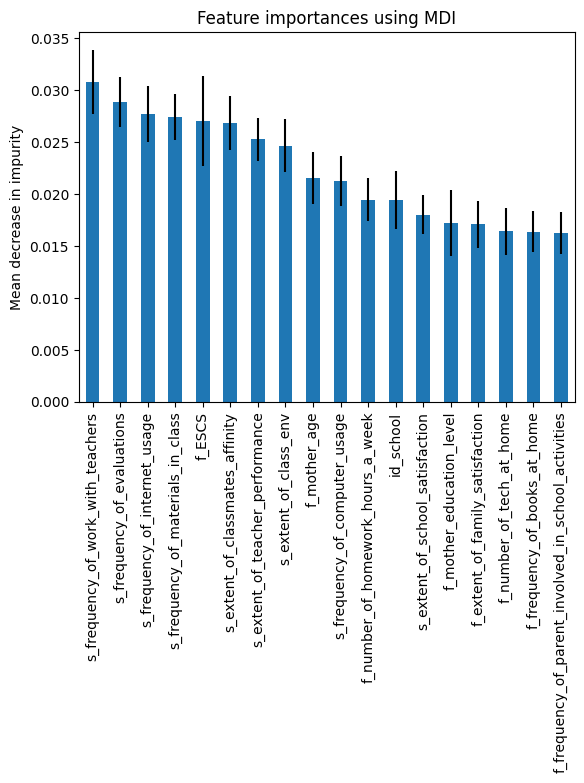

In [92]:
forest_importances = pd.Series(importances, index=get_features(concatenated_df))
forest_std = pd.Series(std, index=get_features(concatenated_df))
forest_df = pd.concat([forest_importances, forest_std], axis=1)
forest_df.columns = ["importance", "std"]
forest_df = forest_df[forest_df["importance"] > 0.015]
forest_df = forest_df.sort_values("importance", ascending=False)
forest_importances = forest_df["importance"]
std = forest_df["std"].to_numpy()

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
# fig.tight_layout()

In [93]:
final_features = [col for col in list(forest_importances.index) if col != "id_school"] + ["s_gender"]
final_features

['s_frequency_of_work_with_teachers',
 's_frequency_of_evaluations',
 's_frequency_of_internet_usage',
 's_frequency_of_materials_in_class',
 'f_ESCS',
 's_extent_of_classmates_affinity',
 's_extent_of_teacher_performance',
 's_extent_of_class_env',
 'f_mother_age',
 's_frequency_of_computer_usage',
 'f_number_of_homework_hours_a_week',
 's_extent_of_school_satisfaction',
 'f_mother_education_level',
 'f_extent_of_family_satisfaction',
 'f_number_of_tech_at_home',
 'f_frequency_of_books_at_home',
 'f_frequency_of_parent_involved_in_school_activities',
 's_gender']

# Bias detection

In [94]:
final_df = concatenated_df[final_features + [target_feature]]
final_df

,s_frequency_of_work_with_teachers,s_frequency_of_evaluations,s_frequency_of_internet_usage,s_frequency_of_materials_in_class,f_ESCS,s_extent_of_classmates_affinity,s_extent_of_teacher_performance,s_extent_of_class_env,f_mother_age,s_frequency_of_computer_usage,f_number_of_homework_hours_a_week,s_extent_of_school_satisfaction,f_mother_education_level,f_extent_of_family_satisfaction,f_number_of_tech_at_home,f_frequency_of_books_at_home,f_frequency_of_parent_involved_in_school_activities,s_gender,level_MAT
id_questionnaire,,,,,,,,,,,,,,,,,,,
1,0.733333,0.740741,0.066667,0.380952,0.235340,0.714286,0.833333,0.791667,43.0,0.111111,14.0,0.944444,7.0,0.700000,3.0,1.000000,0.333333,FEMALE,3.0
2,0.533333,0.888889,0.600000,0.714286,NaN,0.714286,0.800000,0.791667,NaN,0.333333,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,MALE,1.0
3,0.833333,0.750000,0.666667,1.000000,0.261451,0.833333,0.800000,0.833333,45.0,0.666667,9.0,0.888889,3.0,0.291667,4.0,0.444444,0.166667,FEMALE,1.0
4,0.400000,0.541667,0.266667,NaN,0.787122,0.857143,0.800000,0.750000,39.0,0.333333,9.0,0.722222,5.0,1.000000,3.0,0.333333,0.250000,MALE,2.0
5,0.566667,0.888889,0.133333,0.666667,3.151773,0.952381,1.000000,1.000000,39.0,0.000000,6.0,1.000000,9.0,0.833333,7.0,0.555556,0.250000,FEMALE,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20426,0.333333,0.333333,0.333333,NaN,-1.627731,0.333333,0.333333,0.333333,31.0,NaN,4.0,1.000000,3.0,0.791667,4.0,0.333333,0.000000,FEMALE,1.0
20427,0.666667,0.740741,0.133333,0.476190,1.372627,0.857143,0.900000,0.916667,37.0,0.000000,1.0,1.000000,5.0,0.291667,5.0,0.444444,0.000000,FEMALE,2.0
20428,0.518519,0.740741,0.933333,0.777778,NaN,0.666667,0.566667,0.958333,NaN,0.222222,NaN,0.833333,NaN,NaN,NaN,NaN,NaN,MALE,2.0


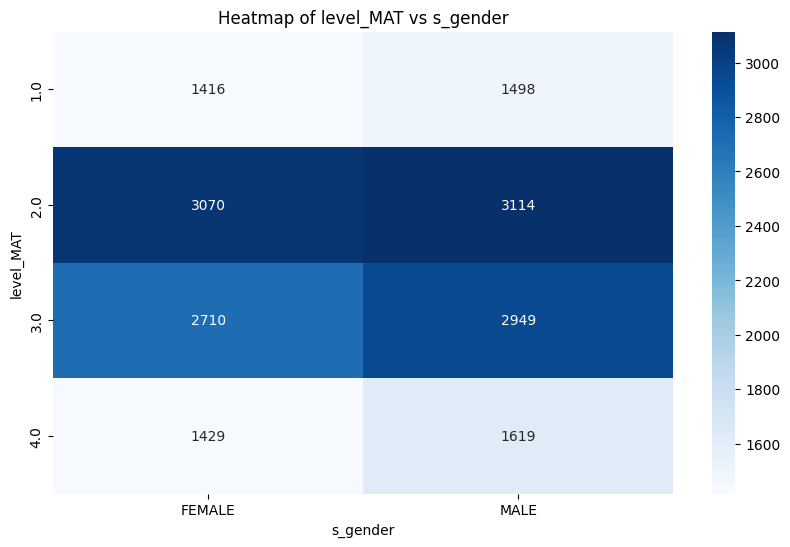

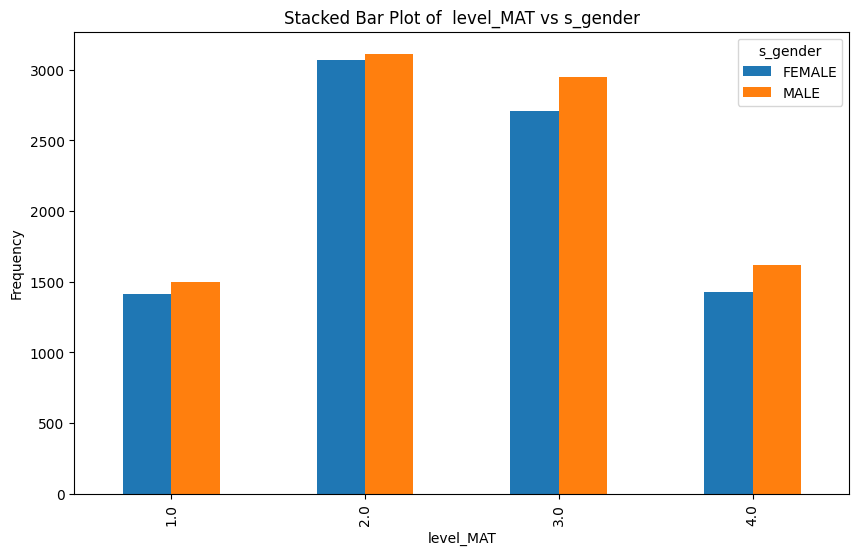

In [187]:
sensitive_feature = "s_gender"

trial_df = final_df[[target_feature, sensitive_feature]]
trial_df = trial_df.dropna()
col_a = trial_df[target_feature]
col_b = trial_df[sensitive_feature]

crosstab = pd.crosstab(col_a, col_b)

# Heatmap of Frequency
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
plt.title(f'Heatmap of {target_feature} vs {sensitive_feature}')
plt.xlabel(sensitive_feature)
plt.ylabel(target_feature)
plt.show()

# Clustered Bar Plot
crosstab.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title(f'Stacked Bar Plot of  {target_feature} vs {sensitive_feature}')
plt.xlabel(target_feature)
plt.ylabel('Frequency')
plt.legend(title=sensitive_feature)
plt.show()


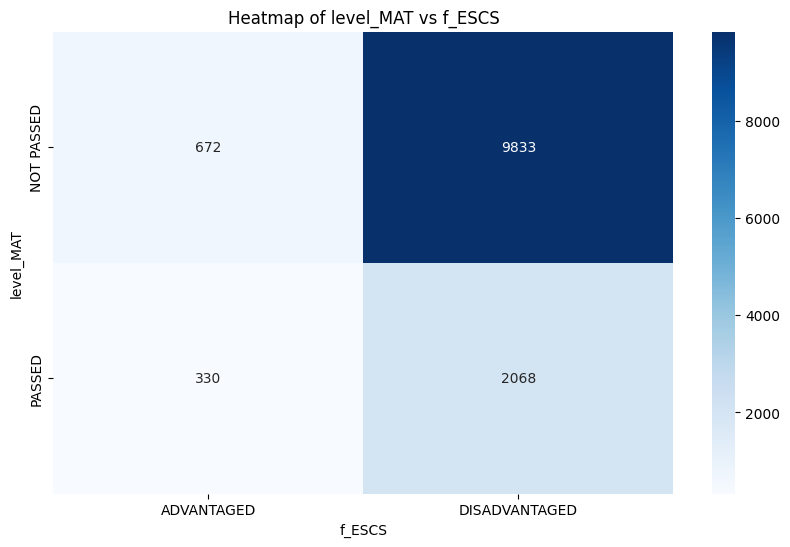

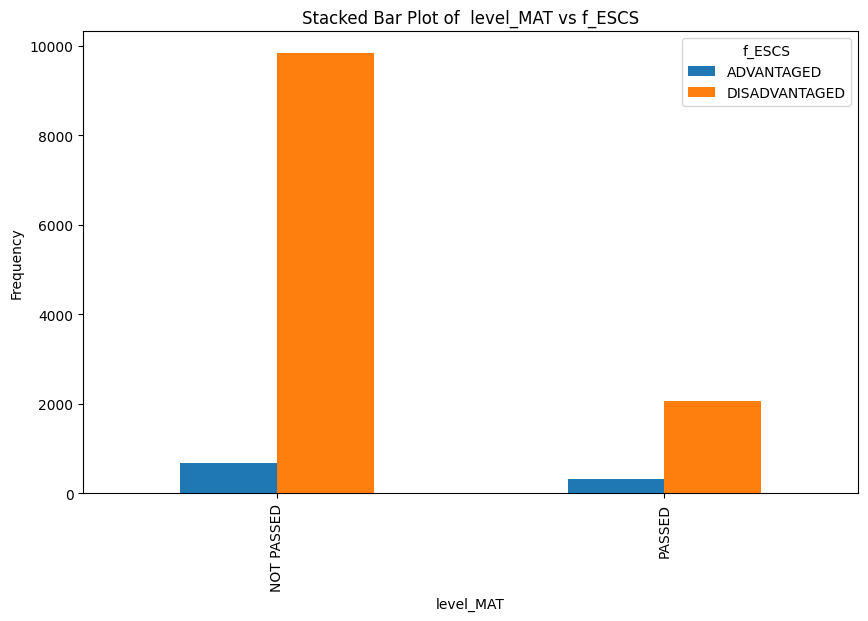

In [101]:
sensitive_feature = "f_ESCS"
favorable_sensitive_label = "ADVANTAGED"
unfavorable_sensitive_label = "DISADVANTAGED"
favorable_class_label = "PASSED"
unfavorable_class_label = "NOT PASSED"

trial_df = final_df[[target_feature, sensitive_feature]]
trial_df = trial_df.dropna()
trial_df[sensitive_feature] = trial_df[sensitive_feature].apply(lambda elem: favorable_sensitive_label if elem > 1.5 else unfavorable_sensitive_label)
trial_df[target_feature] = trial_df[target_feature].apply(lambda elem: favorable_class_label if elem >= 3.5 else unfavorable_class_label)

col_a = trial_df[target_feature]
col_b = trial_df[sensitive_feature]

crosstab = pd.crosstab(col_a, col_b)

# Heatmap of Frequency
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
plt.title(f'Heatmap of {target_feature} vs {sensitive_feature}')
plt.xlabel(sensitive_feature)
plt.ylabel(target_feature)
plt.show()

# Clustered Bar Plot
crosstab.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title(f'Stacked Bar Plot of  {target_feature} vs {sensitive_feature}')
plt.xlabel(target_feature)
plt.ylabel('Frequency')
plt.legend(title=sensitive_feature)
plt.show()

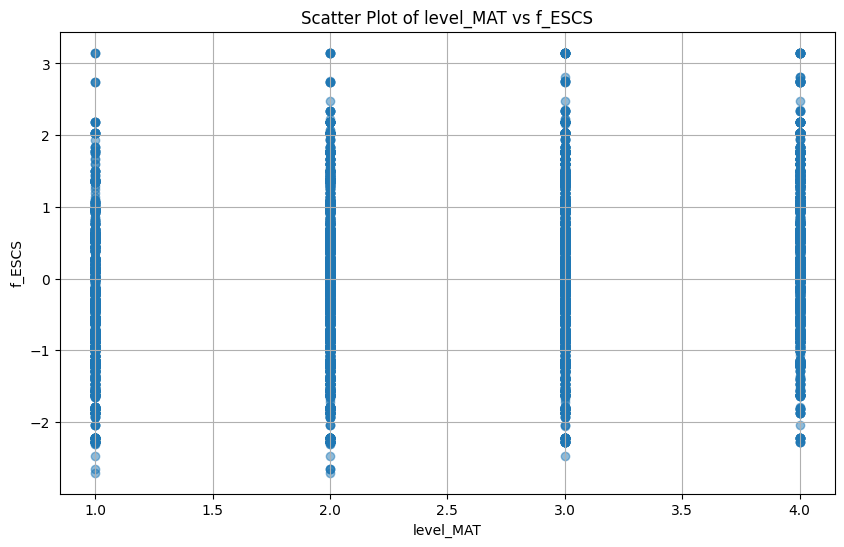

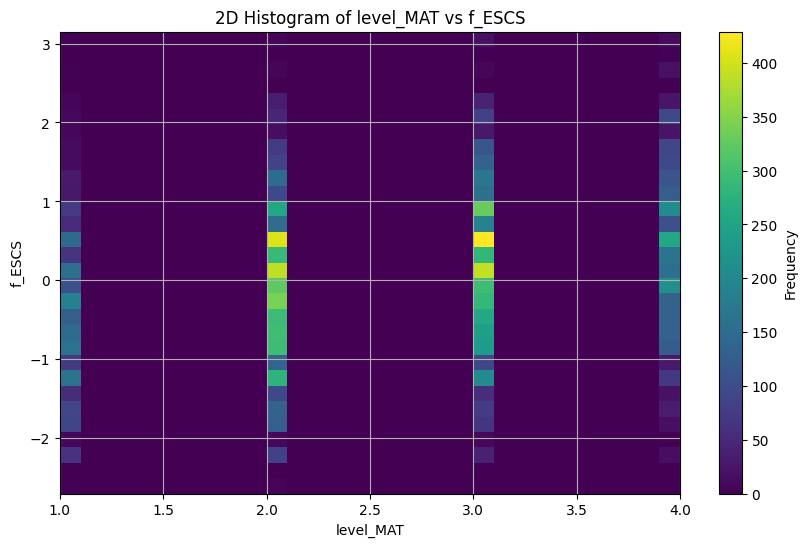

In [97]:
sensitive_feature = "f_ESCS"

trial_df = final_df[[target_feature, sensitive_feature]]
trial_df = trial_df.dropna()
col_a = trial_df[target_feature]
col_b = trial_df[sensitive_feature]

# Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(col_a, col_b, alpha=0.5)
plt.title(f"Scatter Plot of {target_feature} vs {sensitive_feature}")
plt.xlabel(target_feature)
plt.ylabel(sensitive_feature)
plt.grid()
plt.show()

# 2D Histogram (Heatmap)
plt.figure(figsize=(10, 6))
plt.hist2d(col_a, col_b, bins=(30, 30), cmap=plt.cm.viridis)
plt.colorbar(label='Frequency')
plt.title(f"2D Histogram of {target_feature} vs {sensitive_feature}")
plt.xlabel(target_feature)
plt.ylabel(sensitive_feature)
plt.grid()
plt.show()

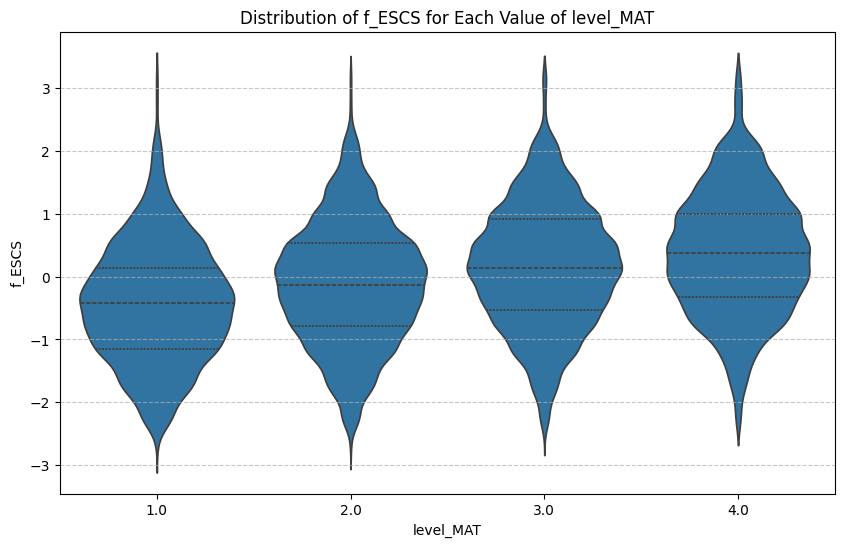

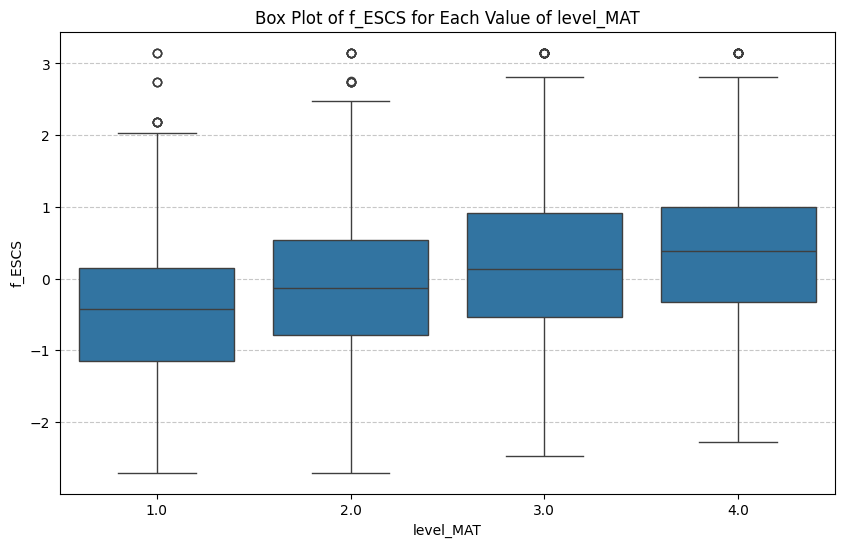

In [189]:
sensitive_feature = "f_ESCS"

plt.figure(figsize=(10, 6))
sns.violinplot(x=target_feature, y=sensitive_feature, data=trial_df, inner="quartile")
plt.title(f'Distribution of {sensitive_feature} for Each Value of {target_feature}')
plt.xlabel(target_feature)
plt.ylabel(sensitive_feature)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=target_feature, y=sensitive_feature, data=trial_df)
plt.title(f'Box Plot of {sensitive_feature} for Each Value of {target_feature}')
plt.xlabel(target_feature)
plt.ylabel(sensitive_feature)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Processing

In [283]:
sensitive_feature = "s_gender"
favorable_sensitive_label = "MALE"
unfavorable_sensitive_label = "FEMALE"

class_feature = target_feature
favorable_class_label = "PASSED"
unfavorable_class_label = "NOT PASSED"

metric = "balanced_accuracy"
fair_metric = "demographic_parity_ratio"

## Utils

In [340]:
def encode_feature(df, feature, favorable_label):

        df_encoded = df.copy()

        # Encode class
        if feature in df_encoded.columns:
            df_encoded[feature] = df_encoded[
                feature
            ].apply(lambda x: 1 if x == favorable_label else 0)
        return df_encoded

In [339]:
def decode_feature(df, feature, favorable_label, unfavorable_label):

        df_decoded = df.copy()

        # Encode class
        if feature in df_decoded.columns:
            df_decoded[feature] = df_decoded[
                feature
            ].apply(lambda x: favorable_label if x == 1 else unfavorable_label)
        return df_decoded

### Estimator

In [341]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric
import pandas as pd

class AIF360SklearnWrapper(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        aif360_model,
        sensitive_feature,
        favorable_class_label,
        unfavorable_class_label,
        favorable_sens_group,
    ):
        self.aif360_model = aif360_model

        self.sensitive_feature = sensitive_feature
        self.favorable_sens_group = favorable_sens_group

        self.class_feature = "label"
        self.favorable_class_label = favorable_class_label
        self.unfavorable_class_label = unfavorable_class_label

        self.ordinal_encoder = None

    def _encode_features(self, df, fit):

        df_encoded = df.copy()

        # Encode class
        if self.class_feature in df_encoded.columns:
            df_encoded[self.class_feature] = df_encoded[
                self.class_feature
            ].apply(lambda x: 1 if x == self.favorable_class_label else 0)
        else:
            df_encoded[self.class_feature] = 0  # or any constant value

        # Encode sensitive feature
        if self.sensitive_feature in df_encoded.select_dtypes(include=['object', 'category']).columns:
            df_encoded[self.sensitive_feature] = df_encoded[
                self.sensitive_feature
            ].apply(lambda x: 1 if x == self.favorable_sens_group else 0)


        # # Encode other columns
        # categorical_cols = df_encoded.select_dtypes(include=['object', 'category']).columns
        # numeric_cols = df_encoded.select_dtypes(exclude=['object', 'category']).columns

        # if fit:
        #     self.ordinal_encoder = OrdinalEncoder()
        #     self.ordinal_encoder.fit(df_encoded[categorical_cols])

        # if len(categorical_cols) > 0:
        #     df_encoded[categorical_cols] = self.ordinal_encoder.transform(df_encoded[categorical_cols])
        # if len(numeric_cols) > 0:
        #     df_encoded[numeric_cols] = df_encoded[numeric_cols]

        # # Check missing values
        # print(df_encoded.isna().sum())
        # df_encoded = df_encoded.set_index(self.sensitive_feature)
        # print(df_encoded.isna().sum())

        return df_encoded

    def fit(self, X, y, **kwargs):
        if not self.sensitive_feature:
            raise ValueError("Protected attribute name must be specified.")

        df_encoded = self._encode_features(df=X.assign(label=y), fit=True)
        # print(df_encoded)
        dataset = BinaryLabelDataset(
            df=df_encoded,
            label_names=[self.class_feature],
            # sensitive_features=[self.sensitive_feature],
            protected_attribute_names=[self.sensitive_feature],
            favorable_label=1,
            unfavorable_label=0
        )
        self.aif360_model= self.aif360_model.fit(dataset, **kwargs)
        return self

    def predict(self, X, decode=False):
        X_encoded = self._encode_features(df=X, fit=False)
        dataset = BinaryLabelDataset(
            df=X_encoded,
            label_names=[self.class_feature],
            # sensitive_features=[self.sensitive_feature],
            protected_attribute_names=[self.sensitive_feature],
            favorable_label=1,
            unfavorable_label=0
        )
        predictions = self.aif360_model.predict(dataset).convert_to_dataframe()[0][self.class_feature]
        predictions = predictions.apply(lambda x: self.favorable_class_label if x == 1 else self.unfavorable_class_label) if decode else predictions
        return predictions

    def predict_proba(self, X):
        if hasattr(self.aif360_model, "predict_proba"):
            X_encoded = self._encode_features(df=X, fit=False)
            dataset = BinaryLabelDataset(
                df=X_encoded,
                label_names=[self.class_feature],
                # sensitive_features=[self.sensitive_feature],
                protected_attribute_names=[self.sensitive_feature],
                favorable_label=1,
                unfavorable_label=0
            )
            probabilities = self.aif360_model.predict_proba(dataset)
            return probabilities
        else:
            raise NotImplementedError("The wrapped model does not support probability prediction.")

    def score(self, X, y):
        y_pred = self.predict(X)
        return (y_pred == y).mean()

### Transformers

In [ ]:
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OrdinalEncoder

from aif360.sklearn.preprocessing import LearnedFairRepresentations


class LFR_wrapper(BaseEstimator, TransformerMixin):
    """
    Wrapper class for LearnedFairRepresentations that allows it to be used with numpy arrays.
    """

    feature_names = []
    enc = None

    def __init__(self, prot_attr, feature_names, **kwargs):
        """
        Initialize the LFR_wrapper.

        Args:
            X: The numpy array of input data.
            y: The numpy array of target labels.
            feature_names: The list of feature names.
            **kwargs: Additional keyword arguments to pass to the LearnedFairRepresentations constructor.
        """
        self.prot_attr = prot_attr
        self.feature_names = feature_names
        self.lfr = LearnedFairRepresentations(
            prot_attr=prot_attr if len(prot_attr) == 1 else "mixin", **kwargs
        )

    def _prepare_dataset(self, X, y=None):
        df = pd.DataFrame(X, columns=self.feature_names)

        if len(self.prot_attr) == 0:
            raise Exception("No sensitive features to mitigate")

        if len(self.prot_attr) > 1:
            df["mixin"] = df[self.prot_attr[0]].astype(str) + df[
                self.prot_attr[1]
            ].astype(str)
            df = df.drop(columns=self.prot_attr)

            self.enc = OrdinalEncoder()
            df["mixin"] = self.enc.fit_transform(df["mixin"].to_numpy().reshape(-1, 1))
            df = df.set_index("mixin")
        else:
            df = df.set_index(self.prot_attr)

        if y is not None:
            df["target"] = y
            df_X, df_y = df.drop(columns=["target"]), df["target"]
        else:
            df_X, df_y = df, None

        return df_X, df_y

    def fit(self, X, y):
        df_X, df_y = self._prepare_dataset(X, y)
        self.lfr.fit(df_X, df_y)
        return self

    def transform(self, X):
        df_X, _ = self._prepare_dataset(X, None)
        transformed_df = self.lfr.transform(df_X)
        return transformed_df.values

    def fit_transform(self, X, y=None):
        df_X, df_y = self._prepare_dataset(X, y)
        transformed_df = self.lfr.fit_transform(df_X, df_y)
        return transformed_df.values


### Metrics

#### Platform

In [ ]:
detection_results = {
    "disparate_impact": [],
    "statistical_parity_difference": []
}


for sens_col, priv_group in sensitive_groups:
    # print(f"{sens_col}: {priv_group}")

    current_df = copy.deepcopy(df)
    current_df[sens_col] = current_df[sens_col].apply(lambda x: 1 if x == priv_group else 0)

    for out_col, out_group in outcome_groups:
        # print(f"{out_col}: {out_group}")

        current_df[out_col] = current_df[out_col].apply(lambda x: 1 if x == out_group else 0)

        current_dataset = BinaryLabelDataset(
            favorable_label=1,
            unfavorable_label=0,
            df=current_df[[sens_col, out_col]],
            label_names=[out_col],
            sensitive_features=[sens_col]
        )

        # Step 2: Compute metrics
        metric = BinaryLabelDatasetMetric(
            current_dataset,
            privileged_groups=[{sens_col: 1}],
            unprivileged_groups=[{sens_col: 0}],
        )

        # Disparate Impact
        disparate_impact = metric.disparate_impact()
        # print(f"Disparate Impact: {disparate_impact}")
        detection_results["disparate_impact"] += [
            {
                "when": {
                    sens_col: priv_group,
                    out_col: out_group
                },
                "value": "NaN" if np.isnan(disparate_impact) else disparate_impact
            }
        ]

        # Statistical Parity Difference
        statistical_parity_difference = metric.statistical_parity_difference()
        # print(f"Statistical Parity Difference: {statistical_parity_difference}")
        detection_results["statistical_parity_difference"] += [
            {
                "when": {
                    sens_col: priv_group,
                    out_col: out_group
                },
                "value": "NaN" if np.isnan(statistical_parity_difference) else statistical_parity_difference
            }
        ]

        # print()
detection_results

In [342]:
def compute_fair_metric(
    fair_metric_name, sensitive_feature, X, y_true, y_pred
):

    # metrics_module = __import__("metrics")
    metrics_module = globals()["metrics"]
    fair_metric = getattr(metrics_module, fair_metric_name)
    
    X_sensitive = encode_feature(X, sensitive_feature, favorable_label=favorable_sensitive_label)
    X_sensitive = X_sensitive[sensitive_feature]

    return fair_metric(
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=X_sensitive,
    )

## Analysis

In [357]:
final_df

,s_frequency_of_work_with_teachers,s_frequency_of_evaluations,s_frequency_of_internet_usage,s_frequency_of_materials_in_class,f_ESCS,s_extent_of_classmates_affinity,s_extent_of_teacher_performance,s_extent_of_class_env,f_mother_age,s_frequency_of_computer_usage,f_number_of_homework_hours_a_week,s_extent_of_school_satisfaction,f_mother_education_level,f_extent_of_family_satisfaction,f_number_of_tech_at_home,f_frequency_of_books_at_home,f_frequency_of_parent_involved_in_school_activities,s_gender,level_MAT
id_questionnaire,,,,,,,,,,,,,,,,,,,
1,0.733333,0.740741,0.066667,0.380952,0.235340,0.714286,0.833333,0.791667,43.0,0.111111,14.0,0.944444,7.0,0.700000,3.0,1.000000,0.333333,FEMALE,3.0
3,0.833333,0.750000,0.666667,1.000000,0.261451,0.833333,0.800000,0.833333,45.0,0.666667,9.0,0.888889,3.0,0.291667,4.0,0.444444,0.166667,FEMALE,1.0
5,0.566667,0.888889,0.133333,0.666667,3.151773,0.952381,1.000000,1.000000,39.0,0.000000,6.0,1.000000,9.0,0.833333,7.0,0.555556,0.250000,FEMALE,4.0
6,0.533333,0.851852,0.133333,0.380952,-1.627731,0.761905,0.866667,1.000000,25.0,0.222222,5.0,1.000000,3.0,0.833333,3.0,0.333333,0.083333,FEMALE,1.0
8,0.633333,0.703704,0.266667,0.666667,-0.358498,0.857143,0.966667,0.833333,37.0,0.333333,10.0,0.833333,7.0,1.000000,3.0,0.555556,0.333333,MALE,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20421,0.566667,0.777778,0.600000,0.476190,-0.764891,0.904762,1.000000,1.000000,41.0,0.111111,14.0,1.000000,5.0,1.000000,4.0,0.222222,0.333333,MALE,2.0
20422,0.700000,0.518519,0.266667,0.380952,-0.048524,0.952381,0.888889,0.916667,36.0,0.222222,2.0,0.944444,4.0,0.708333,5.0,0.555556,0.000000,FEMALE,3.0
20423,0.400000,0.555556,0.400000,0.571429,0.072922,0.809524,1.000000,0.666667,46.0,0.111111,8.0,1.000000,3.0,0.833333,10.0,0.444444,0.000000,MALE,2.0


GOOD FEATURES: 19
s_frequency_of_work_with_teachers                      0.056329
s_frequency_of_evaluations                             0.058632
s_frequency_of_internet_usage                          0.055824
s_frequency_of_materials_in_class                      0.059811
f_ESCS                                                 0.275357
s_extent_of_classmates_affinity                        0.060036
s_extent_of_teacher_performance                        0.059025
s_extent_of_class_env                                  0.059250
f_mother_age                                           0.281534
s_frequency_of_computer_usage                          0.056049
f_number_of_homework_hours_a_week                      0.278445
s_extent_of_school_satisfaction                        0.057396
f_mother_education_level                               0.291082
f_extent_of_family_satisfaction                        0.277547
f_number_of_tech_at_home                               0.281984
f_frequency_of_books_a

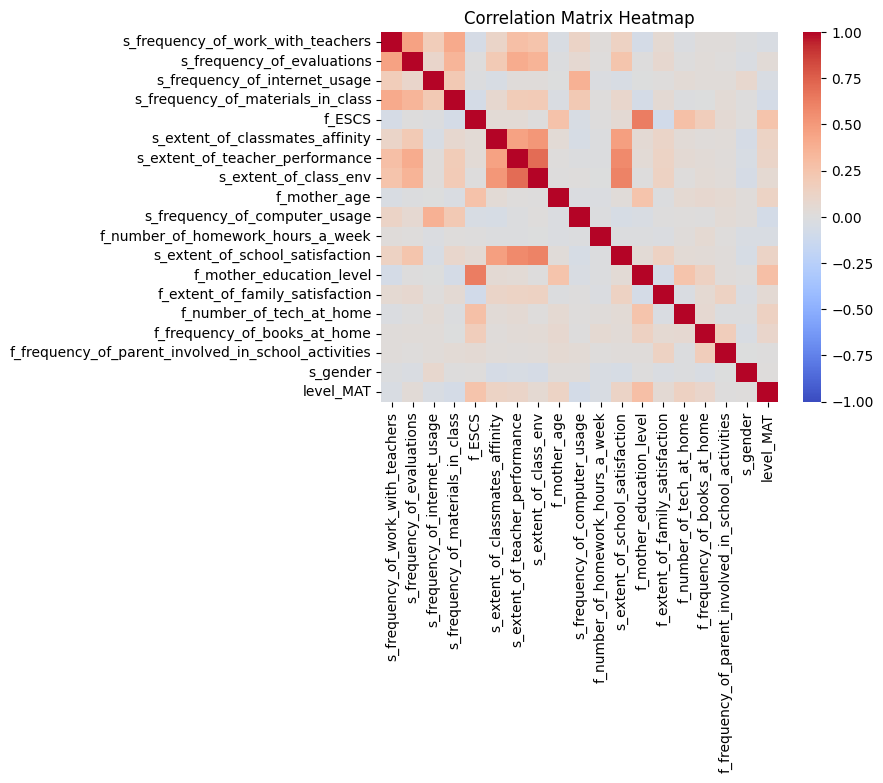

,s_frequency_of_work_with_teachers,s_frequency_of_evaluations,s_frequency_of_internet_usage,s_frequency_of_materials_in_class,f_ESCS,s_extent_of_classmates_affinity,s_extent_of_teacher_performance,s_extent_of_class_env,f_mother_age,s_frequency_of_computer_usage,f_number_of_homework_hours_a_week,s_extent_of_school_satisfaction,f_mother_education_level,f_extent_of_family_satisfaction,f_number_of_tech_at_home,f_frequency_of_books_at_home,f_frequency_of_parent_involved_in_school_activities,s_gender,level_MAT
id_questionnaire,,,,,,,,,,,,,,,,,,,
1,0.733333,0.740741,0.066667,0.380952,0.235340,0.714286,0.833333,0.791667,43.0,0.111111,14.0,0.944444,7.0,0.700000,3.0,1.000000,0.333333,FEMALE,3.0
2,0.533333,0.888889,0.600000,0.714286,NaN,0.714286,0.800000,0.791667,NaN,0.333333,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,MALE,1.0
3,0.833333,0.750000,0.666667,1.000000,0.261451,0.833333,0.800000,0.833333,45.0,0.666667,9.0,0.888889,3.0,0.291667,4.0,0.444444,0.166667,FEMALE,1.0
4,0.400000,0.541667,0.266667,NaN,0.787122,0.857143,0.800000,0.750000,39.0,0.333333,9.0,0.722222,5.0,1.000000,3.0,0.333333,0.250000,MALE,2.0
5,0.566667,0.888889,0.133333,0.666667,3.151773,0.952381,1.000000,1.000000,39.0,0.000000,6.0,1.000000,9.0,0.833333,7.0,0.555556,0.250000,FEMALE,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20426,0.333333,0.333333,0.333333,NaN,-1.627731,0.333333,0.333333,0.333333,31.0,NaN,4.0,1.000000,3.0,0.791667,4.0,0.333333,0.000000,FEMALE,1.0
20427,0.666667,0.740741,0.133333,0.476190,1.372627,0.857143,0.900000,0.916667,37.0,0.000000,1.0,1.000000,5.0,0.291667,5.0,0.444444,0.000000,FEMALE,2.0
20428,0.518519,0.740741,0.933333,0.777778,NaN,0.666667,0.566667,0.958333,NaN,0.222222,NaN,0.833333,NaN,NaN,NaN,NaN,NaN,MALE,2.0


,s_frequency_of_work_with_teachers,s_frequency_of_evaluations,s_frequency_of_internet_usage,s_frequency_of_materials_in_class,f_ESCS,s_extent_of_classmates_affinity,s_extent_of_teacher_performance,s_extent_of_class_env,f_mother_age,s_frequency_of_computer_usage,f_number_of_homework_hours_a_week,s_extent_of_school_satisfaction,f_mother_education_level,f_extent_of_family_satisfaction,f_number_of_tech_at_home,f_frequency_of_books_at_home,f_frequency_of_parent_involved_in_school_activities,s_gender,level_MAT
s_frequency_of_work_with_teachers,1.000000,0.459210,0.184811,0.407241,-0.056927,0.115582,0.284243,0.253826,-0.033653,0.120296,0.023143,0.140080,-0.066000,0.057850,-0.016357,0.017840,0.016874,-0.013262,-0.038320
s_frequency_of_evaluations,0.459210,1.000000,0.097839,0.346366,0.000752,0.208706,0.405473,0.353524,-0.010146,0.064127,0.013561,0.246491,0.002241,0.076432,0.004816,0.024959,0.012819,-0.028531,0.033004
s_frequency_of_internet_usage,0.184811,0.097839,1.000000,0.215844,-0.015618,-0.043809,0.020481,0.022687,-0.006085,0.371735,-0.020469,-0.039423,-0.004143,0.008416,0.040167,0.023850,0.025514,0.084017,-0.036665
s_frequency_of_materials_in_class,0.407241,0.346366,0.215844,1.000000,-0.068230,0.075477,0.192643,0.198315,-0.030786,0.215274,0.013483,0.088556,-0.068052,0.050423,-0.014722,-0.004838,0.039642,0.000793,-0.066594
f_ESCS,-0.056927,0.000752,-0.015618,-0.068230,1.000000,0.040619,0.039800,0.005268,0.261448,-0.044139,0.007309,0.049781,0.627503,-0.087052,0.278867,0.175323,0.047424,0.009554,0.250165
s_extent_of_classmates_affinity,0.115582,0.208706,-0.043809,0.075477,0.040619,1.000000,0.455324,0.512753,0.040068,-0.052212,-0.008666,0.471544,0.048646,0.115887,0.037754,0.021444,0.030362,-0.055421,0.132252
s_extent_of_teacher_performance,0.284243,0.405473,0.020481,0.192643,0.039800,0.455324,1.000000,0.699774,0.011708,-0.011863,-0.008315,0.572676,0.039756,0.132071,0.047904,0.033481,0.015670,-0.044767,0.110412
s_extent_of_class_env,0.253826,0.353524,0.022687,0.198315,0.005268,0.512753,0.699774,1.000000,0.000189,0.014833,-0.004051,0.603268,0.000608,0.135805,0.014492,0.039548,0.026473,-0.055349,0.059059
f_mother_age,-0.033653,-0.010146,-0.006085,-0.030786,0.261448,0.040068,0.011708,0.000189,1.000000,-0.018088,-0.019828,0.024990,0.250886,-0.013724,0.058864,0.072558,0.060719,0.021320,0.126018
s_frequency_of_computer_usage,0.120296,0.064127,0.371735,0.215274,-0.044139,-0.052212,-0.011863,0.014833,-0.018088,1.000000,-0.011977,-0.051609,-0.035688,0.007575,0.012460,0.004609,0.040685,0.019260,-0.072532


(                  s_frequency_of_work_with_teachers  \
 id_questionnaire                                      
 1                                          0.733333   
 2                                          0.533333   
 3                                          0.833333   
 4                                          0.400000   
 5                                          0.566667   
 ...                                             ...   
 20426                                      0.333333   
 20427                                      0.666667   
 20428                                      0.518519   
 20429                                      0.633333   
 20430                                      0.629630   
 
                   s_frequency_of_evaluations  s_frequency_of_internet_usage  \
 id_questionnaire                                                              
 1                                   0.740741                       0.066667   
 2                            

In [199]:
compute_exploratory_analysis(df=final_df, column_pattern=None, missing_threshold=0.3, annot=False)

In [203]:
final_df = final_df[~final_df.isnull().any(axis=1)]

GOOD FEATURES: 19
s_frequency_of_work_with_teachers                      0.0
s_frequency_of_evaluations                             0.0
s_frequency_of_internet_usage                          0.0
s_frequency_of_materials_in_class                      0.0
f_ESCS                                                 0.0
s_extent_of_classmates_affinity                        0.0
s_extent_of_teacher_performance                        0.0
s_extent_of_class_env                                  0.0
f_mother_age                                           0.0
s_frequency_of_computer_usage                          0.0
f_number_of_homework_hours_a_week                      0.0
s_extent_of_school_satisfaction                        0.0
f_mother_education_level                               0.0
f_extent_of_family_satisfaction                        0.0
f_number_of_tech_at_home                               0.0
f_frequency_of_books_at_home                           0.0
f_frequency_of_parent_involved_in_scho

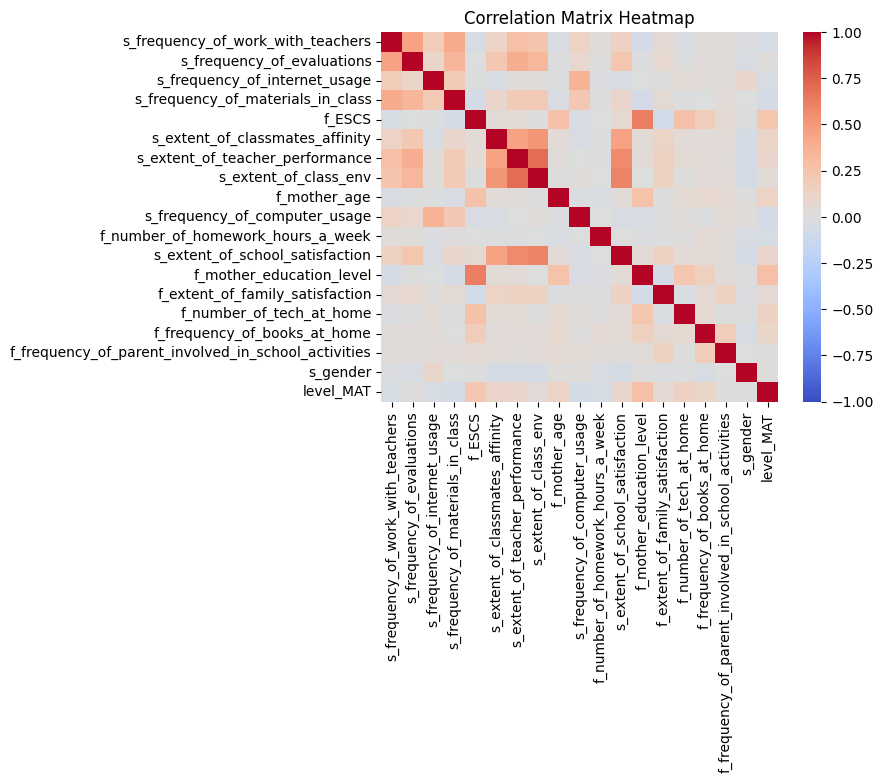

,s_frequency_of_work_with_teachers,s_frequency_of_evaluations,s_frequency_of_internet_usage,s_frequency_of_materials_in_class,f_ESCS,s_extent_of_classmates_affinity,s_extent_of_teacher_performance,s_extent_of_class_env,f_mother_age,s_frequency_of_computer_usage,f_number_of_homework_hours_a_week,s_extent_of_school_satisfaction,f_mother_education_level,f_extent_of_family_satisfaction,f_number_of_tech_at_home,f_frequency_of_books_at_home,f_frequency_of_parent_involved_in_school_activities,s_gender,level_MAT
id_questionnaire,,,,,,,,,,,,,,,,,,,
1,0.733333,0.740741,0.066667,0.380952,0.235340,0.714286,0.833333,0.791667,43.0,0.111111,14.0,0.944444,7.0,0.700000,3.0,1.000000,0.333333,FEMALE,3.0
3,0.833333,0.750000,0.666667,1.000000,0.261451,0.833333,0.800000,0.833333,45.0,0.666667,9.0,0.888889,3.0,0.291667,4.0,0.444444,0.166667,FEMALE,1.0
5,0.566667,0.888889,0.133333,0.666667,3.151773,0.952381,1.000000,1.000000,39.0,0.000000,6.0,1.000000,9.0,0.833333,7.0,0.555556,0.250000,FEMALE,4.0
6,0.533333,0.851852,0.133333,0.380952,-1.627731,0.761905,0.866667,1.000000,25.0,0.222222,5.0,1.000000,3.0,0.833333,3.0,0.333333,0.083333,FEMALE,1.0
8,0.633333,0.703704,0.266667,0.666667,-0.358498,0.857143,0.966667,0.833333,37.0,0.333333,10.0,0.833333,7.0,1.000000,3.0,0.555556,0.333333,MALE,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20421,0.566667,0.777778,0.600000,0.476190,-0.764891,0.904762,1.000000,1.000000,41.0,0.111111,14.0,1.000000,5.0,1.000000,4.0,0.222222,0.333333,MALE,2.0
20422,0.700000,0.518519,0.266667,0.380952,-0.048524,0.952381,0.888889,0.916667,36.0,0.222222,2.0,0.944444,4.0,0.708333,5.0,0.555556,0.000000,FEMALE,3.0
20423,0.400000,0.555556,0.400000,0.571429,0.072922,0.809524,1.000000,0.666667,46.0,0.111111,8.0,1.000000,3.0,0.833333,10.0,0.444444,0.000000,MALE,2.0


,s_frequency_of_work_with_teachers,s_frequency_of_evaluations,s_frequency_of_internet_usage,s_frequency_of_materials_in_class,f_ESCS,s_extent_of_classmates_affinity,s_extent_of_teacher_performance,s_extent_of_class_env,f_mother_age,s_frequency_of_computer_usage,f_number_of_homework_hours_a_week,s_extent_of_school_satisfaction,f_mother_education_level,f_extent_of_family_satisfaction,f_number_of_tech_at_home,f_frequency_of_books_at_home,f_frequency_of_parent_involved_in_school_activities,s_gender,level_MAT
s_frequency_of_work_with_teachers,1.000000,0.454881,0.194741,0.409276,-0.054629,0.125635,0.284706,0.256114,-0.037594,0.126924,0.024993,0.136178,-0.068564,0.056726,-0.017440,0.023068,0.017585,-0.018127,-0.052970
s_frequency_of_evaluations,0.454881,1.000000,0.106232,0.351169,-0.000939,0.221110,0.397563,0.342555,-0.012102,0.080795,0.014494,0.237172,0.003207,0.077667,0.000708,0.028708,0.017756,-0.035529,0.014032
s_frequency_of_internet_usage,0.194741,0.106232,1.000000,0.206295,-0.012901,-0.043188,0.022901,0.018326,-0.008697,0.366037,-0.019355,-0.033456,-0.005847,0.015617,0.045162,0.025437,0.026814,0.086346,-0.039068
s_frequency_of_materials_in_class,0.409276,0.351169,0.206295,1.000000,-0.068555,0.099953,0.201062,0.211431,-0.033654,0.229184,0.013167,0.099923,-0.069164,0.051873,-0.014363,-0.007351,0.038761,-0.002908,-0.065283
f_ESCS,-0.054629,-0.000939,-0.012901,-0.068555,1.000000,0.039126,0.042015,0.006251,0.266225,-0.037662,-0.003042,0.056717,0.621918,-0.086076,0.268389,0.177241,0.058164,0.006280,0.241087
s_extent_of_classmates_affinity,0.125635,0.221110,-0.043188,0.099953,0.039126,1.000000,0.457112,0.518564,0.038003,-0.035870,-0.010784,0.459867,0.045788,0.123810,0.033261,0.024182,0.034539,-0.056301,0.113418
s_extent_of_teacher_performance,0.284706,0.397563,0.022901,0.201062,0.042015,0.457112,1.000000,0.700419,0.017997,-0.001503,-0.010408,0.572681,0.036255,0.136448,0.047870,0.036880,0.023407,-0.054769,0.094313
s_extent_of_class_env,0.256114,0.342555,0.018326,0.211431,0.006251,0.518564,0.700419,1.000000,0.002250,0.021759,-0.003077,0.605949,-0.002109,0.140228,0.014887,0.038779,0.035032,-0.059657,0.035256
f_mother_age,-0.037594,-0.012102,-0.008697,-0.033654,0.266225,0.038003,0.017997,0.002250,1.000000,-0.021918,-0.027460,0.031414,0.257911,-0.014695,0.056860,0.073622,0.060336,0.014927,0.127296
s_frequency_of_computer_usage,0.126924,0.080795,0.366037,0.229184,-0.037662,-0.035870,-0.001503,0.021759,-0.021918,1.000000,-0.007628,-0.040981,-0.034161,0.015375,0.020655,0.001636,0.043040,0.021234,-0.072849


(                  s_frequency_of_work_with_teachers  \
 id_questionnaire                                      
 1                                          0.733333   
 3                                          0.833333   
 5                                          0.566667   
 6                                          0.533333   
 8                                          0.633333   
 ...                                             ...   
 20421                                      0.566667   
 20422                                      0.700000   
 20423                                      0.400000   
 20424                                      0.500000   
 20427                                      0.666667   
 
                   s_frequency_of_evaluations  s_frequency_of_internet_usage  \
 id_questionnaire                                                              
 1                                   0.740741                       0.066667   
 3                            

In [204]:
compute_exploratory_analysis(df=final_df, column_pattern=None, missing_threshold=0.3, annot=False)